# Task 01 – Python Programming, Data Analysis & Visualization
**Devixo Solutions – AI/ML Internship Program**

**Dataset:** Diabetes 130 US Hospitals for Years 1999–2008 (Kaggle: `brandao/diabetes`)
**Author:** *Muhammad Ali*

---
## PART 1 – Data Loading & Data Understanding

### 1.1 Import Required Libraries
- **pandas** – load and work with tables (DataFrames)
- **numpy** – numerical operations
- **matplotlib / seaborn** – charts (used later in Part 4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Show all columns when printing tables (this dataset has 50 columns)
pd.set_option("display.max_columns", None)

# Print library versions so the results can be reproduced
print("pandas :", pd.__version__)
print("numpy  :", np.__version__)

pandas : 2.2.3
numpy  : 2.1.3


### 1.2 Load the Dataset
**Loading decisions:**
- `keep_default_na=False` – by default pandas turns the text `"None"` into NaN. In this dataset `"None"` in `max_glu_serum` and `A1Cresult` means *the test was not performed*, which is real information. We keep the raw text and handle the hidden missing values (`"?"`) deliberately in Part 2.
- `low_memory=False` – makes pandas read the whole column before deciding its type, which avoids mixed-type warnings.
- **Integrity check** – the original file has 101,766 rows and 50 columns. If the loaded file is different (for example an incomplete upload), the notebook stops here instead of producing wrong results.

In [2]:
from pathlib import Path

# The notebook looks for the file in these places (local repo layout first, then Google Colab upload)
candidates = [
    Path("../dataset/diabetic_data.csv"),
    Path("dataset/diabetic_data.csv"),
    Path("diabetic_data.csv"),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("diabetic_data.csv not found. Current folder: " + str(Path.cwd()))

df = pd.read_csv(DATA_PATH, keep_default_na=False, low_memory=False)
print("Loaded from:", DATA_PATH)

# ---- Integrity check against the published dataset size ----
EXPECTED_SHAPE = (101766, 50)
EXPECTED_NUMERIC = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
                    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]

assert df.shape == EXPECTED_SHAPE, (
    f"Unexpected shape {df.shape}; expected {EXPECTED_SHAPE}. The file may be incomplete or modified - re-download it.")
bad = [c for c in EXPECTED_NUMERIC if not pd.api.types.is_numeric_dtype(df[c])]
assert not bad, f"These columns should be numeric but are not: {bad}. The file may be corrupted - re-download it."
print("Integrity check passed:", df.shape)

Loaded from: diabetic_data.csv
Integrity check passed: (101766, 50)


### 1.3 Display Dataset Records

In [3]:
print("First 5 records:")
display(df.head())

First 5 records:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
print("Last 5 records:")
display(df.tail())

Last 5 records:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,MC,?,51,0,16,0,0,0,250.13,291,458,9,None,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,MC,?,33,3,18,0,0,1,560,276,787,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,MC,?,53,0,9,1,0,0,38,590,296,13,None,None,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,None,None,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,?,?,13,3,3,0,0,0,530,530,787,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


In [5]:
print("Random sample of 5 records (random_state=42 so it is repeatable):")
display(df.sample(5, random_state=42))

Random sample of 5 records (random_state=42 so it is repeatable):


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
35956,110939484,19274094,Caucasian,Female,[70-80),?,1,1,6,11,UN,InternalMedicine,68,0,20,0,0,0,250.8,599,263,5,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
60927,170328306,65634327,Caucasian,Male,[50-60),?,1,1,1,1,HM,?,20,0,7,0,0,0,780,427,E941,8,None,None,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
79920,245688426,100657359,Caucasian,Female,[60-70),?,3,6,1,4,HM,?,21,3,23,1,0,2,715,733,724,7,None,None,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
50078,150826224,83144448,Caucasian,Male,[30-40),?,2,1,1,12,CP,Gastroenterology,28,0,19,0,0,1,494,277,117,7,None,None,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
44080,135993852,65234214,AfricanAmerican,Female,[60-70),?,1,2,7,1,?,?,21,0,6,0,0,0,403,584,428,7,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,<30


**Observation:** Each row is one hospital visit (an *encounter*) of a patient with diabetes, described by 50 columns: patient details (race, gender, age bracket), hospital details (days in hospital, number of lab procedures and medications), diagnosis codes, many columns about diabetes medicines, and the outcome `readmitted`. Two things stand out. First, `age` is not a number but a bracket such as `[0-10)`. Second, the column `weight` shows `?` in every row displayed, so `?` is being used as a placeholder for missing data.

### 1.4 Display Dataset Information

In [6]:
rows, cols = df.shape
print(f"Number of rows    : {rows:,}")
print(f"Number of columns : {cols}")
print("\nColumn names:")
print(list(df.columns))

Number of rows    : 101,766
Number of columns : 50

Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [7]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
# Missing values as pandas sees them
missing_pandas = df.isna().sum()
print("Missing values detected by pandas (isna):", int(missing_pandas.sum()))

Missing values detected by pandas (isna): 0


**Check for hidden missing values.** `isna()` only finds real NaN values. Some datasets use a placeholder symbol instead. Let us check whether the symbol `"?"` appears.

In [9]:
# Count "?" placeholders per column (only columns that have them)
question_marks = (df == "?").sum()
question_marks = question_marks[question_marks > 0].sort_values(ascending=False)

hidden_missing = pd.DataFrame({
    "question_mark_count": question_marks,
    "percent_of_rows": (question_marks / len(df) * 100).round(2),
})
display(hidden_missing)

,question_mark_count,percent_of_rows
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


**Observation:** `isna()` found **0** missing values, but 7 columns contain the placeholder `?`, in 192,849 cells in total: `weight` (98,569 cells, 96.86%), `medical_specialty` (49.08%), `payer_code` (39.56%), `race` (2.23%), `diag_3` (1.40%), `diag_2` (0.35%) and `diag_1` (0.02%). This is a problem because pandas only recognises real NaN values. If I had trusted `isna()`, I would have concluded the data was complete and my statistics and charts would have treated `?` as a real category.

### 1.5 Check Dataset Shape

In [10]:
print("Shape (rows, columns):", df.shape)
print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

Shape (rows, columns): (101766, 50)
Number of Rows    : 101,766
Number of Columns : 50


### 1.6 Identify Column Types
Pandas data types are not always the *real* meaning of a column. Three columns are stored as numbers but are actually **IDs or codes** (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`). Calculating an average of a code has no meaning, so they are treated as categorical. The two ID columns (`encounter_id`, `patient_nbr`) only identify records and are not analysed statistically.

In [11]:
id_cols = ["encounter_id", "patient_nbr"]
coded_categorical = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]

# Numeric columns that are real measurements/counts
numeric_cols = [c for c in df.select_dtypes(include="number").columns
                if c not in id_cols + coded_categorical]

# Text columns are categorical, plus the numeric-looking codes above
categorical_cols = list(df.select_dtypes(exclude="number").columns) + coded_categorical

# Date/time columns (none expected in this dataset)
datetime_cols = list(df.select_dtypes(include="datetime").columns)

print(f"ID columns ({len(id_cols)}):", id_cols)
print(f"\nNumerical columns ({len(numeric_cols)}):", numeric_cols)
print(f"\nCategorical columns ({len(categorical_cols)}):")
print(categorical_cols)
print(f"\nDate/time columns ({len(datetime_cols)}):", datetime_cols if datetime_cols else "None found")

ID columns (2): ['encounter_id', 'patient_nbr']

Numerical columns (8): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical columns (40):
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

Date/time columns (0): None found


**Why column types matter:** numerical columns support mean, median, standard deviation and correlation; categorical columns support counts, the mode and group comparisons. Choosing the wrong type gives wrong results; for example, the average of `discharge_disposition_id` is meaningless because its numbers are only labels. The dataset has 8 numerical measurement columns, 2 ID columns, and 40 categorical columns (37 text columns plus 3 numeric-looking codes). There are no date/time columns.

*Note:* `age` is stored as text brackets such as `[70-80)`. It is an **ordered** categorical variable. We deal with it in Part 2.

### Part 1 Summary
- **Rows:** 101,766 (each row is one hospital visit)
- **Columns:** 50
- **Real missing values found by pandas (`isna`):** 0
- **Hidden missing values (`?`):** 192,849 cells in 7 columns: `weight`, `medical_specialty`, `payer_code`, `race`, `diag_3`, `diag_2`, `diag_1`
- **Numerical columns (8):** `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_outpatient`, `number_emergency`, `number_inpatient`, `number_diagnoses`
- **Categorical columns (40):** 37 text columns plus 3 numeric codes (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`)
- **Date/time columns:** none
- **Issues to handle in Part 2:** `?` placeholders, the almost-empty `weight` column, `age` stored as text brackets, numeric codes that are really categories, and unclear column names

---
## PART 2 – Data Cleaning & Preprocessing

**Approach:** the raw DataFrame `df` is never changed. All cleaning is done on a copy called `df_clean`, so the original can always be compared with the cleaned version.

A running **cleaning log** records every action (what, how many rows/values, why). It becomes the evidence table for the report.

In [12]:
df_clean = df.copy()
rows_before = len(df_clean)

cleaning_log = []   # each entry: step, action, rows_or_values_affected, reason

def log(step, action, affected, reason):
    cleaning_log.append({"step": step, "action": action, "affected": affected, "reason": reason})

print("Working copy created. Rows:", rows_before)

Working copy created. Rows: 101766


### 2.1 Check Missing Values
Step 1: convert the hidden `"?"` placeholders into real missing values (NaN) so pandas can count and handle them.
Step 2: report which columns are affected, how many values, and what percentage.

The text `"None"` in `max_glu_serum` and `A1Cresult` is **not** converted, because it means "test not performed" (real information).

In [13]:
n_question = int((df_clean == "?").sum().sum())
df_clean = df_clean.replace("?", np.nan)

missing = df_clean.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": (missing / len(df_clean) * 100).round(2),
})
display(missing_table)
print(f"Total '?' converted to NaN: {n_question:,}")
log("2.1", "Converted '?' placeholders to NaN", n_question, "Pandas cannot count or handle '?' as missing")

,missing_count,missing_percent
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


Total '?' converted to NaN: 192,849


In [14]:
# Proof that "None" is a real category, not missing data
for col in ["max_glu_serum", "A1Cresult"]:
    print(col)
    print(df_clean[col].value_counts(dropna=False).to_string(), "\n")

max_glu_serum
max_glu_serum
None    96420
Norm     2597
>200     1485
>300     1264 

A1Cresult
A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812 



**Observation:** The missing values are very uneven. `weight` is missing in 96.86% of rows, `medical_specialty` in 49.08% and `payer_code` in 39.56%, so these three need a decision at column level. `race` (2.23%), `diag_3` (1.40%), `diag_2` (0.35%) and `diag_1` (0.02%) have only small amounts missing. Because the amounts differ so much, one method for all columns would be wrong: an almost-empty column is better dropped, a half-empty category is better labelled "Unknown", and a handful of rows missing an essential field can simply be removed. The value `"None"` in `max_glu_serum` and `A1Cresult` is not missing data; it means the test was not performed.

### 2.2 Handle Missing Values
Each column gets its own decision, based on how much is missing and what the missing value probably means.

| Column | Missing | Decision | Reason |
|---|---|---|---|
| `weight` | about 97% | **Drop the column** | Almost empty; filling it would invent data. Any statistic would be unreliable. |
| `medical_specialty` | about 49% | Fill with `"Unknown"` | Too many missing to delete rows; the mode would invent a specialty for half the patients. |
| `payer_code` | about 40% | Fill with `"Unknown"` | Same reasoning; the payer is a category and cannot be averaged. |
| `race` | about 2% | Fill with `"Unknown"` | Small amount; guessing a race with the mode would be wrong and unfair to individuals. |
| `diag_2`, `diag_3` | under 2% | Fill with `"Not recorded"` | Checked below: they are mostly missing when the patient had very few diagnoses, so "no additional diagnosis" is the likely meaning. |
| `diag_1` | 21 rows | **Remove those rows** | The primary diagnosis is a core field. These patients had other diagnoses recorded, so it is truly missing. 21 rows is a negligible loss. |

Mean and median cannot be used here because these columns are categories (text), not numbers. Forward/backward fill is not suitable because the rows are not ordered in time.

In [15]:
# Evidence: are diag_2 / diag_3 missing because the patient had few diagnoses?
for col in ["diag_2", "diag_3"]:
    miss_rows = df_clean[df_clean[col].isna()]
    print(f"{col}: {len(miss_rows)} missing. Their number_diagnoses values (smallest first):")
    print(miss_rows["number_diagnoses"].value_counts().sort_index().head(5).to_string(), "\n")

print("diag_1 missing rows - number_diagnoses values:")
print(df_clean[df_clean["diag_1"].isna()]["number_diagnoses"].value_counts().sort_index().to_string())

diag_2: 358 missing. Their number_diagnoses values (smallest first):
number_diagnoses
1    219
2      2
3     11
4     17
5     63 

diag_3: 1423 missing. Their number_diagnoses values (smallest first):
number_diagnoses
1     219
2    1023
3      12
4      24
5     108 

diag_1 missing rows - number_diagnoses values:
number_diagnoses
4    3
5    2
6    2
7    3
8    8
9    3


In [16]:
# 1) Drop the weight column
n = int(df_clean["weight"].isna().sum())
df_clean = df_clean.drop(columns=["weight"])
log("2.2", "Dropped column 'weight'", n, "About 97% missing; cannot be filled reliably")

# 2) Fill categorical columns with an explicit label
fill_unknown = ["medical_specialty", "payer_code", "race"]
for col in fill_unknown:
    n = int(df_clean[col].isna().sum())
    df_clean[col] = df_clean[col].fillna("Unknown")
    log("2.2", f"Filled '{col}' missing with 'Unknown'", n, "Keeps the rows; avoids inventing a value")

for col in ["diag_2", "diag_3"]:
    n = int(df_clean[col].isna().sum())
    df_clean[col] = df_clean[col].fillna("Not recorded")
    log("2.2", f"Filled '{col}' missing with 'Not recorded'", n, "Mostly patients with few diagnoses")

# 3) Remove rows with no primary diagnosis
n = int(df_clean["diag_1"].isna().sum())
df_clean = df_clean.dropna(subset=["diag_1"])
log("2.2", "Removed rows with missing 'diag_1'", n, "Primary diagnosis is essential; only 21 rows")

print("Remaining missing values:", int(df_clean.isna().sum().sum()))
print("Shape now:", df_clean.shape)

Remaining missing values: 0
Shape now: (101745, 49)


### 2.3 Check Duplicate Records
Two checks: completely identical rows, and repeated `encounter_id` (each hospital visit should appear once).
We also look at **repeated patients**: the same person can have many visits. These are *not* duplicates, because each row is a different hospital stay, so they are kept. It is a limitation to mention: visits from the same patient are not fully independent.

In [17]:
dup_rows = int(df_clean.duplicated().sum())
dup_encounters = int(df_clean["encounter_id"].duplicated().sum())
print("Fully identical duplicate rows :", dup_rows)
print("Repeated encounter_id          :", dup_encounters)

unique_patients = df_clean["patient_nbr"].nunique()
print(f"\nUnique patients: {unique_patients:,} for {len(df_clean):,} visits")
print("Most visits by one patient:", df_clean["patient_nbr"].value_counts().max())

# Remove duplicates only if they exist
if dup_rows > 0:
    df_clean = df_clean.drop_duplicates()
    log("2.3", "Removed duplicate rows", dup_rows, "Identical records")
else:
    log("2.3", "No duplicate rows found - nothing removed", 0, "Checked with duplicated()")

# Verify
print("\nDuplicates after check:", int(df_clean.duplicated().sum()))

Fully identical duplicate rows : 0
Repeated encounter_id          : 0

Unique patients: 71,509 for 101,745 visits
Most visits by one patient: 40

Duplicates after check: 0


**Observation:** After cleaning there are 101,745 visits but only 71,509 unique patients, and one patient has 40 visits. These rows are not duplicates because each has a different `encounter_id` and describes a different hospital stay. They do matter for the analysis, though: visits from the same patient are similar to each other, so the rows are not fully independent. This can make patterns look stronger than they are, and in Part 3.8 a single patient accounts for the five highest `number_emergency` values. The original study behind this dataset (see `description.pdf`) kept only the first visit of each patient for its readmission analysis. In this task all visits are kept for descriptive analysis, and this is stated as a limitation.

### 2.4 Check Data Types
Problems to look for: numbers stored as text, dates stored as strings, categories stored as numbers.
- The 3 `*_id` code columns are numbers but are really categories -> convert to text categories.
- Text columns -> `category` dtype (less memory, and correct meaning).
- `age` -> **ordered** category (youngest to oldest) so charts sort correctly.
- No date columns exist, so there is nothing to convert to datetime.

In [18]:
print("Data types before conversion:")
print(df_clean.dtypes.astype(str).value_counts().to_string())

# 1) Numeric codes -> categories
for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    df_clean[col] = df_clean[col].astype(str).astype("category")

# 2) Age: ordered category
age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
             "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]
assert set(df_clean["age"].unique()) <= set(age_order), "Unexpected age bracket found"
df_clean["age"] = pd.Categorical(df_clean["age"], categories=age_order, ordered=True)

# 3) Remaining text columns -> category
text_cols = [c for c in df_clean.select_dtypes(include=["object", "string"]).columns
             if c not in ["encounter_id", "patient_nbr"]]
for col in text_cols:
    df_clean[col] = df_clean[col].astype("category")

log("2.4", "Converted 3 code columns, age (ordered) and text columns to category", len(text_cols) + 4,
    "Codes are not quantities; age brackets have a natural order")

print("\nData types after conversion:")
print(df_clean.dtypes.astype(str).value_counts().to_string())

Data types before conversion:
object    36
int64     13

Data types after conversion:
category    39
int64       10


### 2.5 Rename Columns
Some names are unclear or awkward to use in code:
- `patient_nbr` -> `patient_id`
- `diag_1`, `diag_2`, `diag_3` -> `primary_diagnosis`, `secondary_diagnosis`, `additional_diagnosis`
- `max_glu_serum` -> `max_glucose_serum`, `A1Cresult` -> `a1c_result`, `diabetesMed` -> `diabetes_med` (consistent lowercase_with_underscores)
- Medicine columns with a hyphen (e.g. `glyburide-metformin`) -> underscore, because a hyphen is read as a minus sign in Python code.

Values are also made clearer: the label `"None"` in `max_glucose_serum` and `a1c_result` becomes `"Not tested"`, because "None" looks like a missing value but means the test was not done.

In [19]:
rename_map = {
    "patient_nbr": "patient_id",
    "diag_1": "primary_diagnosis",
    "diag_2": "secondary_diagnosis",
    "diag_3": "additional_diagnosis",
    "max_glu_serum": "max_glucose_serum",
    "A1Cresult": "a1c_result",
    "diabetesMed": "diabetes_med",
    "glyburide-metformin": "glyburide_metformin",
    "glipizide-metformin": "glipizide_metformin",
    "glimepiride-pioglitazone": "glimepiride_pioglitazone",
    "metformin-rosiglitazone": "metformin_rosiglitazone",
    "metformin-pioglitazone": "metformin_pioglitazone",
}
# Safety check: every old name must really exist
missing_names = [c for c in rename_map if c not in df_clean.columns]
assert not missing_names, f"These columns do not exist: {missing_names}"

df_clean = df_clean.rename(columns=rename_map)

# Make the "None" label clearer
for col in ["max_glucose_serum", "a1c_result"]:
    df_clean[col] = df_clean[col].cat.rename_categories({"None": "Not tested"})

log("2.5", "Renamed 12 columns; relabelled 'None' as 'Not tested' in 2 columns", 12,
    "Clearer, consistent names; avoids confusing 'None' with missing")
print(list(df_clean.columns))

['encounter_id', 'patient_id', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'primary_diagnosis', 'secondary_diagnosis', 'additional_diagnosis', 'number_diagnoses', 'max_glucose_serum', 'a1c_result', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide_metformin', 'glipizide_metformin', 'glimepiride_pioglitazone', 'metformin_rosiglitazone', 'metformin_pioglitazone', 'change', 'diabetes_med', 'readmitted']


### 2.6 Check Invalid Values
Look for values that make no logical sense. Unusual is **not** the same as invalid: a very long stay or many medications can be real. We only remove values that are impossible, and we inspect the unusual ones first.

In [20]:
# 1) Impossible values in count columns (negative numbers, zero-day stays)
count_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
              "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]
print("Negative values per column:")
print((df_clean[count_cols] < 0).sum().to_string())
print("\nHospital stays shorter than 1 day:", int((df_clean["time_in_hospital"] < 1).sum()))

# 2) Valid categories
print("\nGender values:")
print(df_clean["gender"].value_counts().to_string())

# 3) Range of each numeric column (min and max)
display(df_clean[count_cols].agg(["min", "max"]).T)

Negative values per column:
time_in_hospital      0
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0

Hospital stays shorter than 1 day: 0

Gender values:
gender
Female             54703
Male               47039
Unknown/Invalid        3


,min,max
time_in_hospital,1,14
num_lab_procedures,1,132
num_procedures,0,6
num_medications,1,81
number_outpatient,0,42
number_emergency,0,76
number_inpatient,0,21
number_diagnoses,1,16


**Decision on gender:** the value `"Unknown/Invalid"` is not a usable category, and gender cannot be guessed. There are only a few such rows, so they are removed (explained in the log).

In [21]:
n = int((df_clean["gender"] == "Unknown/Invalid").sum())
df_clean = df_clean[df_clean["gender"] != "Unknown/Invalid"].copy()
df_clean["gender"] = df_clean["gender"].cat.remove_unused_categories()
log("2.6", "Removed rows with gender 'Unknown/Invalid'", n, "Not a valid category; cannot be inferred; negligible row count")
print("Rows removed:", n, "| Shape now:", df_clean.shape)

Rows removed: 3 | Shape now: (101742, 49)


**Outliers are inspected, not deleted.** Below we count how many values fall outside the usual range using the IQR rule (a common statistical rule). We keep them: they are plausible hospital data, and removing them would bias the results. We will examine them again in Part 3 (EDA).

In [22]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < low) | (series > high)).sum()), low, high

rows = []
for col in count_cols:
    n_out, low, high = iqr_outliers(df_clean[col])
    rows.append({"column": col, "values_outside_IQR_range": n_out,
                 "percent": round(n_out / len(df_clean) * 100, 2),
                 "lower_limit": round(low, 1), "upper_limit": round(high, 1),
                 "max_value": df_clean[col].max()})
display(pd.DataFrame(rows).set_index("column"))
log("2.6", "Outliers inspected but kept", "see table", "Plausible real values; removal would bias results")

,values_outside_IQR_range,percent,lower_limit,upper_limit,max_value
column,,,,,
time_in_hospital,2252,2.21,-4.0,12.0,14
num_lab_procedures,143,0.14,-8.0,96.0,132
num_procedures,4954,4.87,-3.0,5.0,6
num_medications,2557,2.51,-5.0,35.0,81
number_outpatient,16737,16.45,0.0,0.0,42
number_emergency,11379,11.18,0.0,0.0,76
number_inpatient,7046,6.93,-1.5,2.5,21
number_diagnoses,281,0.28,1.5,13.5,16


**Note on reading this table:** the IQR rule works poorly for columns where most values are 0 (the visit-count columns). When the upper limit is 0 or very small, almost any non-zero value is flagged, even though a patient with one prior visit is completely normal. A flagged value is a *reason to look*, not proof of an error.

**Code columns and discharge types – decision for Task 01.** The three code columns (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`) are kept exactly as provided, and no rows are removed because of them. The meaning of each code comes from a separate ID-mapping file that was not reviewed in this task, so any special handling would be a guess. The frequency of each code is shown below as evidence.

In [23]:
# Frequency of each code (top 10) in the three coded columns
for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    vc = df_clean[col].value_counts()
    print(f"--- {col}  ({df_clean[col].nunique()} distinct codes) ---")
    print(pd.DataFrame({"count": vc.head(10), "percent": (vc.head(10) / len(df_clean) * 100).round(1)}).to_string(), "\n")

--- admission_type_id  (8 distinct codes) ---
                   count  percent
admission_type_id                
1                  53977     53.1
3                  18861     18.5
2                  18478     18.2
6                   5290      5.2
5                   4785      4.7
8                    320      0.3
7                     21      0.0
4                     10      0.0 

--- discharge_disposition_id  (26 distinct codes) ---
                          count  percent
discharge_disposition_id                
1                         60226     59.2
3                         13950     13.7
6                         12898     12.7
18                         3690      3.6
2                          2127      2.1
22                         1992      2.0
11                         1642      1.6
5                          1182      1.2
25                          988      1.0
4                           815      0.8 

--- admission_source_id  (17 distinct codes) ---
               

**Limitation:** some codes in these columns may mean "not available" or may mark patients who died or were discharged to hospice. Patients who died cannot be readmitted, so including them can distort readmission results; the authors of the original study (`description.pdf`) removed those cases. Because this was not checked here, the readmission rates in Part 3 should be read with this limitation in mind.

### 2.7 Verify the Cleaned Dataset

In [24]:
print("=== Cleaned dataset verification ===")
print("Missing values  :", int(df_clean.isna().sum().sum()))
print("Duplicate rows  :", int(df_clean.duplicated().sum()))
print(f"Shape before    : {df.shape}")
print(f"Shape after     : {df_clean.shape}")
print(f"Rows removed    : {rows_before - len(df_clean)}  ({(rows_before - len(df_clean)) / rows_before * 100:.3f}%)")
print(f"Columns removed : {df.shape[1] - df_clean.shape[1]}")
print("\nData types:")
print(df_clean.dtypes.astype(str).value_counts().to_string())

=== Cleaned dataset verification ===
Missing values  : 0
Duplicate rows  : 0
Shape before    : (101766, 50)
Shape after     : (101742, 49)
Rows removed    : 24  (0.024%)
Columns removed : 1

Data types:
category    39
int64       10


In [25]:
# Basic statistics of the numeric columns
display(df_clean[count_cols].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101742.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101742.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0
num_procedures,101742.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0
num_medications,101742.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0
number_outpatient,101742.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0
number_emergency,101742.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0
number_inpatient,101742.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101742.0,7.42,1.93,1.0,6.0,8.0,9.0,16.0


In [26]:
# Cleaning log - evidence of every action taken
log_table = pd.DataFrame(cleaning_log)
display(log_table)

,step,action,affected,reason
0,2.1,Converted '?' placeholders to NaN,192849,Pandas cannot count or handle '?' as missing
1,2.2,Dropped column 'weight',98569,About 97% missing; cannot be filled reliably
2,2.2,Filled 'medical_specialty' missing with 'Unknown',49949,Keeps the rows; avoids inventing a value
3,2.2,Filled 'payer_code' missing with 'Unknown',40256,Keeps the rows; avoids inventing a value
4,2.2,Filled 'race' missing with 'Unknown',2273,Keeps the rows; avoids inventing a value
5,2.2,Filled 'diag_2' missing with 'Not recorded',358,Mostly patients with few diagnoses
6,2.2,Filled 'diag_3' missing with 'Not recorded',1423,Mostly patients with few diagnoses
7,2.2,Removed rows with missing 'diag_1',21,Primary diagnosis is essential; only 21 rows
8,2.3,No duplicate rows found - nothing removed,0,Checked with duplicated()
9,2.4,"Converted 3 code columns, age (ordered) and te...",39,Codes are not quantities; age brackets have a ...


In [27]:
# Save the cleaned dataset (used later by the Streamlit app)
CLEAN_PATH = "diabetic_data_cleaned.csv"
df_clean.to_csv(CLEAN_PATH, index=False)
print("Saved:", CLEAN_PATH)
# Note: CSV does not store 'category' types, so the app must set them again when loading.

Saved: diabetic_data_cleaned.csv


### Part 2 Summary
- **Problems found in the raw data:** hidden missing values (`?`, 192,849 cells in 7 columns), an almost-empty column (`weight`), 3 rows with gender `Unknown/Invalid`, 21 rows without a primary diagnosis, numeric codes stored as numbers, `age` stored as text, unclear or inconsistent column names, and repeated patients. No negative values and no duplicate rows were found.
- **Cleaning decisions and why:** dropped `weight` (97% missing); filled `medical_specialty`, `payer_code` and `race` with "Unknown" (a mode would invent values); filled `diag_2` and `diag_3` with "Not recorded" (many of these patients had very few diagnoses); removed rows with no `diag_1` (essential field) and rows with invalid gender (cannot be guessed); converted codes and text to categories, `age` to an ordered category; renamed 12 columns for clarity.
- **Rows removed in total:** 24 (0.024%): 21 without a primary diagnosis and 3 with invalid gender. Final shape: 101,742 rows x 49 columns.
- **Columns removed:** 1 (`weight`).
- **Deliberately kept:** outliers (they are plausible hospital data and removing them would bias results), repeated patients (different hospital stays; mentioned as a limitation), and the code columns exactly as provided (see the decision in 2.6).
- **Result:** 0 missing values and 0 duplicate rows in the cleaned data; a full cleaning log is shown in 2.7.

---
## PART 3 – Exploratory Data Analysis (EDA)

Questions this section answers: What does the data contain? Which variables matter? Which categories are most frequent? What are the highest and lowest values? Are there unusual values or outliers? Which variables are related?

**Derived columns (feature creation, not cleaning).** Two helper columns are added to make analysis possible:
- `age_midpoint` – the middle of each age bracket (e.g. `[70-80)` -> 75), so age can be used in calculations and correlations.
- `readmitted_30d` – 1 if the patient was readmitted in under 30 days, otherwise 0. The average of this column is the **30-day readmission rate**.

In [28]:
age_midpoint_map = {"[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35, "[40-50)": 45,
                    "[50-60)": 55, "[60-70)": 65, "[70-80)": 75, "[80-90)": 85, "[90-100)": 95}
df_clean["age_midpoint"] = df_clean["age"].astype(str).map(age_midpoint_map).astype(int)
df_clean["readmitted_30d"] = (df_clean["readmitted"] == "<30").astype(int)

num_cols = count_cols   # the 8 numeric measurement columns from Part 2
print("Rows:", len(df_clean))
print("Overall 30-day readmission rate: {:.2f}%".format(df_clean["readmitted_30d"].mean() * 100))
print()
print(df_clean["readmitted"].value_counts().to_string())

Rows: 101742
Overall 30-day readmission rate: 11.16%

readmitted
NO     54849
>30    35541
<30    11352


### 3.1 Descriptive Statistics
Mean, median, mode, minimum, maximum, range, standard deviation and variance for the 8 numeric columns.

In [29]:
desc = pd.DataFrame({
    "mean": df_clean[num_cols].mean(),
    "median": df_clean[num_cols].median(),
    "mode": df_clean[num_cols].mode().iloc[0],
    "min": df_clean[num_cols].min(),
    "max": df_clean[num_cols].max(),
    "range": df_clean[num_cols].max() - df_clean[num_cols].min(),
    "std": df_clean[num_cols].std(),
    "variance": df_clean[num_cols].var(),
}).round(2)
display(desc)

,mean,median,mode,min,max,range,std,variance
time_in_hospital,4.40,4.0,3,1,14,13,2.99,8.91
num_lab_procedures,43.10,44.0,1,1,132,131,19.67,387.07
num_procedures,1.34,1.0,0,0,6,6,1.71,2.91
num_medications,16.02,15.0,13,1,81,80,8.13,66.06
number_outpatient,0.37,0.0,0,0,42,42,1.27,1.61
number_emergency,0.20,0.0,0,0,76,76,0.93,0.87
number_inpatient,0.64,0.0,0,0,21,21,1.26,1.59
number_diagnoses,7.42,8.0,9,1,16,15,1.93,3.74


**Observation:** The typical patient stays about 4 days (mean 4.40, median 4, range 1 to 14), receives about 16 medications (mean 16.02, median 15, range 1 to 81) and about 43 lab procedures (mean 43.10, median 44, range 1 to 132). Patients have 7.42 diagnoses on average. The three visit-count columns (`number_outpatient`, `number_emergency`, `number_inpatient`) have a median of 0 and means between 0.20 and 0.64: most patients had no earlier visits in the previous year, but a few had many (up to 76 emergency visits). The mode of `num_lab_procedures` is 1, far from its median of 44. This means a large group of patients had only one lab procedure, so here the mode shows a spike at the low end, not a typical value.

### 3.2 Mean
Formula: **Mean = Σx / n** (sum of all values divided by the number of values). Below the formula is calculated by hand for one column and compared with pandas.

In [30]:
col = "time_in_hospital"
manual_mean = df_clean[col].sum() / len(df_clean)
print(f"Sum of {col}: {df_clean[col].sum():,}   n = {len(df_clean):,}")
print(f"Manual mean : {manual_mean:.4f}")
print(f"Pandas mean : {df_clean[col].mean():.4f}")
print(f"Match: {np.isclose(manual_mean, df_clean[col].mean())}")

Sum of time_in_hospital: 447,270   n = 101,742
Manual mean : 4.3961
Pandas mean : 4.3961
Match: True


**Observation:** The hand calculation (447,270 total days / 101,742 visits = 4.3961) matches pandas, so the formula is understood and the code is correct. The average stay is 4.40 days. For this column the mean is a good summary, because it is close to the median (4). For `number_emergency` the mean (0.20) says little about a typical patient, because most patients have 0.

### 3.3 Median
The median is the middle value when the data is sorted. When a column has extreme values (a long right tail), the mean is pulled upward but the median is not. **Skewness** measures this: a value above 0 means a long tail to the right.

In [31]:
mm = pd.DataFrame({
    "mean": df_clean[num_cols].mean(),
    "median": df_clean[num_cols].median(),
    "skewness": df_clean[num_cols].skew(),
}).round(2)
mm["mean_minus_median"] = (mm["mean"] - mm["median"]).round(2)
display(mm.sort_values("skewness", ascending=False))

,mean,median,skewness,mean_minus_median
number_emergency,0.20,0.0,22.86,0.20
number_outpatient,0.37,0.0,8.83,0.37
number_inpatient,0.64,0.0,3.61,0.64
num_medications,16.02,15.0,1.33,1.02
num_procedures,1.34,1.0,1.32,0.34
time_in_hospital,4.40,4.0,1.13,0.40
num_lab_procedures,43.10,44.0,-0.24,-0.90
number_diagnoses,7.42,8.0,-0.88,-0.58


**Observation:** The visit-count columns are very skewed to the right: `number_emergency` has skewness 22.86, `number_outpatient` 8.83 and `number_inpatient` 3.61. For these columns the median is 0 while the mean is 0.20 to 0.64, because a small number of patients with many visits pull the mean up. This is an example from my own data of why the median is more useful than the mean when extreme values are present. `num_medications` is moderately skewed (mean 16.02 vs median 15), and `num_lab_procedures` and `number_diagnoses` are slightly skewed to the left, with the median above the mean.

### 3.4 Mode
The most frequent value. It is the main summary for categorical columns. Top 5 values (with percentage of all rows) for the most important categorical columns:

In [32]:
cat_to_check = ["gender", "race", "age", "readmitted", "payer_code", "medical_specialty",
                "primary_diagnosis", "a1c_result", "change", "diabetes_med"]
for col in cat_to_check:
    vc = df_clean[col].value_counts()
    top = pd.DataFrame({"count": vc.head(5), "percent": (vc.head(5) / len(df_clean) * 100).round(1)})
    print(f"--- {col}  (distinct values: {df_clean[col].nunique()}) ---")
    print(top.to_string(), "\n")

--- gender  (distinct values: 2) ---
        count  percent
gender                
Female  54703     53.8
Male    47039     46.2 

--- race  (distinct values: 6) ---
                 count  percent
race                           
Caucasian        76092     74.8
AfricanAmerican  19201     18.9
Unknown           2269      2.2
Hispanic          2035      2.0
Other             1505      1.5 

--- age  (distinct values: 10) ---
         count  percent
age                    
[70-80)  26062     25.6
[60-70)  22475     22.1
[50-60)  17254     17.0
[80-90)  17192     16.9
[40-50)   9683      9.5 

--- readmitted  (distinct values: 3) ---
            count  percent
readmitted                
NO          54849     53.9
>30         35541     34.9
<30         11352     11.2 

--- payer_code  (distinct values: 18) ---
            count  percent
payer_code                
Unknown     40244     39.6
MC          32432     31.9
HM           6273      6.2
SP           5007      4.9
BC           4655    

**Observation:** Female patients are slightly more common (53.8%). Caucasian is the most common race (74.8%), then African American (18.9%). Most patients are older: the brackets 50 to 90 contain about 82% of all visits, and the most common bracket is 70 to 80 (25.6%). For the outcome, 53.9% were not readmitted, 34.9% were readmitted after more than 30 days, and 11.2% within 30 days. 83.3% of patients had no HbA1c test, 77.0% received diabetes medication, and medication was changed in 46.2% of visits. `payer_code` is unknown for 39.6% and `medical_specialty` for 49.1% of visits, which limits any analysis using these columns. `primary_diagnosis` has 716 distinct codes, so only the top few can be charted; the most common is ICD-9 code 428 (6.7%), followed by 414 (6.5%).

### 3.5 Standard Deviation and Variance
Standard deviation shows how far values typically are from the mean. Columns are on different scales (days vs counts), so their standard deviations cannot be compared directly. The **coefficient of variation** (std / mean) puts them on the same scale.

In [33]:
var_tbl = pd.DataFrame({
    "mean": df_clean[num_cols].mean(),
    "std": df_clean[num_cols].std(),
    "variance": df_clean[num_cols].var(),
})
var_tbl["coef_of_variation"] = var_tbl["std"] / var_tbl["mean"]
display(var_tbl.round(2).sort_values("coef_of_variation", ascending=False))

,mean,std,variance,coef_of_variation
number_emergency,0.20,0.93,0.87,4.70
number_outpatient,0.37,1.27,1.61,3.43
number_inpatient,0.64,1.26,1.59,1.99
num_procedures,1.34,1.71,2.91,1.27
time_in_hospital,4.40,2.99,8.91,0.68
num_medications,16.02,8.13,66.06,0.51
num_lab_procedures,43.10,19.67,387.07,0.46
number_diagnoses,7.42,1.93,3.74,0.26


**Observation:** The visit-count columns vary the most relative to their size: `number_emergency` has a coefficient of variation of 4.70, `number_outpatient` 3.43 and `number_inpatient` 1.99. `number_diagnoses` varies the least (0.26). `num_lab_procedures` has the largest raw standard deviation (19.67), but that is because its values are on a larger scale, which is why the coefficient of variation is the fairer comparison. The variance values (for example 387.07 for lab procedures) are the squared standard deviation and are harder to interpret directly.

### 3.6 Correlation Analysis
Correlation ranges from -1 (perfect negative) through 0 (no linear relationship) to +1 (perfect positive). It measures **association, not cause**. Pearson correlation is used on the 8 numeric columns plus `age_midpoint` and `readmitted_30d`.

In [34]:
corr_cols = num_cols + ["age_midpoint", "readmitted_30d"]
corr = df_clean[corr_cols].corr()
display(corr.round(2))

# Strongest pairs (each pair listed once)
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
pairs = upper.rename("correlation").to_frame()
pairs["abs_correlation"] = pairs["correlation"].abs()
print("Strongest relationships:")
display(pairs.sort_values("abs_correlation", ascending=False).head(8)[["correlation"]].round(3))

print("Relationship of each variable with 30-day readmission:")
display(corr["readmitted_30d"].drop("readmitted_30d").sort_values(key=abs, ascending=False).round(3).to_frame("correlation"))

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_midpoint,readmitted_30d
time_in_hospital,1.00,0.32,0.19,0.47,-0.01,-0.01,0.07,0.22,0.11,0.04
num_lab_procedures,0.32,1.00,0.06,0.27,-0.01,-0.00,0.04,0.15,0.02,0.02
num_procedures,0.19,0.06,1.00,0.39,-0.02,-0.04,-0.07,0.07,-0.03,-0.01
num_medications,0.47,0.27,0.39,1.00,0.05,0.01,0.06,0.26,0.04,0.04
number_outpatient,-0.01,-0.01,-0.02,0.05,1.00,0.09,0.11,0.09,0.02,0.02
number_emergency,-0.01,-0.00,-0.04,0.01,0.09,1.00,0.27,0.06,-0.09,0.06
number_inpatient,0.07,0.04,-0.07,0.06,0.11,0.27,1.00,0.10,-0.04,0.17
number_diagnoses,0.22,0.15,0.07,0.26,0.09,0.06,0.10,1.00,0.24,0.05
age_midpoint,0.11,0.02,-0.03,0.04,0.02,-0.09,-0.04,0.24,1.00,0.02
readmitted_30d,0.04,0.02,-0.01,0.04,0.02,0.06,0.17,0.05,0.02,1.00


Strongest relationships:


,,correlation
time_in_hospital,num_medications,0.466
num_procedures,num_medications,0.386
time_in_hospital,num_lab_procedures,0.318
num_lab_procedures,num_medications,0.268
number_emergency,number_inpatient,0.267
num_medications,number_diagnoses,0.262
number_diagnoses,age_midpoint,0.243
time_in_hospital,number_diagnoses,0.220


Relationship of each variable with 30-day readmission:


,correlation
number_inpatient,0.165
number_emergency,0.061
number_diagnoses,0.050
time_in_hospital,0.044
num_medications,0.038
num_lab_procedures,0.020
number_outpatient,0.019
age_midpoint,0.018
num_procedures,-0.012


**Observation:** No pair of variables is strongly correlated (none above 0.5). The strongest is `time_in_hospital` with `num_medications` (0.47, moderate positive): longer stays go together with more medications. Next are `num_procedures` with `num_medications` (0.39), `time_in_hospital` with `num_lab_procedures` (0.32), `number_emergency` with `number_inpatient` (0.27), and `number_diagnoses` with age (0.24, older patients have more diagnoses). For 30-day readmission, the strongest correlation is with `number_inpatient` (0.17, weak); all other variables are below 0.07, which is close to no linear relationship. This does not prove the variables are unrelated; correlation only detects straight-line relationships, and the group comparisons in 3.7 show clearer patterns. These are associations, not causes.

### 3.7 Group Comparisons
Which groups have the highest and lowest averages? Small groups are unreliable, so groups with fewer than 1,000 patients are left out of the specialty comparison.

In [35]:
def group_summary(by, min_count=1):
    g = df_clean.groupby(by, observed=True).agg(
        patients=("readmitted_30d", "size"),
        avg_days_in_hospital=("time_in_hospital", "mean"),
        avg_medications=("num_medications", "mean"),
        readmission_rate_pct=("readmitted_30d", lambda s: s.mean() * 100),
    ).round(2)
    return g[g["patients"] >= min_count]

print("By age group:")
display(group_summary("age"))

By age group:


,patients,avg_days_in_hospital,avg_medications,readmission_rate_pct
age,,,,
[0-10),161,2.55,6.18,1.86
[10-20),691,3.19,8.28,5.79
[20-30),1656,3.56,11.97,14.25
[30-40),3775,3.80,14.09,11.23
[40-50),9683,4.04,15.39,10.60
[50-60),17254,4.13,16.59,9.67
[60-70),22475,4.38,17.15,11.13
[70-80),26062,4.59,16.41,11.77
[80-90),17192,4.81,15.33,12.08


In [36]:
print("By gender:")
display(group_summary("gender"))
print("By race:")
display(group_summary("race"))

By gender:


,patients,avg_days_in_hospital,avg_medications,readmission_rate_pct
gender,,,,
Female,54703,4.48,16.19,11.24
Male,47039,4.30,15.83,11.06


By race:


,patients,avg_days_in_hospital,avg_medications,readmission_rate_pct
race,,,,
AfricanAmerican,19201,4.51,15.37,11.22
Asian,640,3.99,13.29,10.16
Caucasian,76092,4.39,16.29,11.29
Hispanic,2035,4.06,14.03,10.32
Other,1505,4.28,15.18,9.63
Unknown,2269,4.29,15.82,8.29


In [37]:
# Prior inpatient visits, capped at 3+ so groups are large enough
df_clean["prior_inpatient_group"] = np.minimum(df_clean["number_inpatient"], 3).astype(str).replace("3", "3+")
print("By number of prior inpatient visits in the previous year:")
display(group_summary("prior_inpatient_group"))

print("By HbA1c test result:")
display(group_summary("a1c_result"))

print("By whether diabetes medication was changed / prescribed:")
display(group_summary("change"))
display(group_summary("diabetes_med"))

By number of prior inpatient visits in the previous year:


,patients,avg_days_in_hospital,avg_medications,readmission_rate_pct
prior_inpatient_group,,,,
0,67617,4.21,15.64,8.44
1,19515,4.67,16.40,12.92
2,7564,4.82,17.03,17.44
3+,7046,4.97,17.52,25.65


By HbA1c test result:


,patients,avg_days_in_hospital,avg_medications,readmission_rate_pct
a1c_result,,,,
>7,3812,4.89,16.84,10.05
>8,8214,4.75,16.11,9.87
Not tested,84727,4.31,15.95,11.42
Norm,4989,4.92,16.52,9.64


By whether diabetes medication was changed / prescribed:


,patients,avg_days_in_hospital,avg_medications,readmission_rate_pct
change,,,,
Ch,47001,4.75,18.19,11.82
No,54741,4.09,14.16,10.59


,patients,avg_days_in_hospital,avg_medications,readmission_rate_pct
diabetes_med,,,,
No,23396,4.05,13.24,9.60
Yes,78346,4.50,16.85,11.62


In [38]:
spec = group_summary("medical_specialty", min_count=1000)
spec = spec.drop(index="Unknown", errors="ignore")
print("Specialties with at least 1,000 patients: ", len(spec))
print("\nLongest average hospital stay:")
display(spec.sort_values("avg_days_in_hospital", ascending=False).head(5))
print("Shortest average hospital stay:")
display(spec.sort_values("avg_days_in_hospital").head(5))
print("Highest readmission rate:")
display(spec.sort_values("readmission_rate_pct", ascending=False).head(5))
print("Lowest readmission rate:")
display(spec.sort_values("readmission_rate_pct").head(5))

Specialties with at least 1,000 patients:  9

Longest average hospital stay:


,patients,avg_days_in_hospital,avg_medications,readmission_rate_pct
medical_specialty,,,,
Nephrology,1612,5.02,17.77,15.32
InternalMedicine,14631,4.58,14.75,11.24
Surgery-General,3099,4.55,16.82,11.04
Emergency/Trauma,7564,4.36,14.40,11.18
Family/GeneralPractice,7440,4.36,14.34,11.87


Shortest average hospital stay:


,patients,avg_days_in_hospital,avg_medications,readmission_rate_pct
medical_specialty,,,,
Radiologist,1140,3.48,18.66,9.04
Cardiology,5351,3.53,17.06,7.94
Orthopedics-Reconstructive,1233,3.92,20.31,7.46
Orthopedics,1400,3.98,20.71,10.79
Emergency/Trauma,7564,4.36,14.40,11.18


Highest readmission rate:


,patients,avg_days_in_hospital,avg_medications,readmission_rate_pct
medical_specialty,,,,
Nephrology,1612,5.02,17.77,15.32
Family/GeneralPractice,7440,4.36,14.34,11.87
InternalMedicine,14631,4.58,14.75,11.24
Emergency/Trauma,7564,4.36,14.40,11.18
Surgery-General,3099,4.55,16.82,11.04


Lowest readmission rate:


,patients,avg_days_in_hospital,avg_medications,readmission_rate_pct
medical_specialty,,,,
Orthopedics-Reconstructive,1233,3.92,20.31,7.46
Cardiology,5351,3.53,17.06,7.94
Radiologist,1140,3.48,18.66,9.04
Orthopedics,1400,3.98,20.71,10.79
Surgery-General,3099,4.55,16.82,11.04


**Observation:**
- **Age:** the average stay rises from 2.55 days (ages 0-10) to 4.81 days (80-90). The average number of medications is highest at ages 60-70 (17.15). Readmission rates are between about 10% and 14% for adults, with the highest at ages 20-30 (14.25%, 1,656 patients). The lowest rate, 1.86% at ages 0-10, comes from only 161 patients, so it should not be over-interpreted.
- **Gender:** nearly identical (readmission 11.24% for females, 11.06% for males).
- **Race:** readmission rates range from 8.29% to 11.29%. The groups `Asian` (640 patients) and `Unknown` (2,269) are small, so those differences are less reliable.
- **Earlier inpatient visits:** the clearest pattern. The 30-day readmission rate is 8.44% for patients with no earlier inpatient visit, 12.92% with one, 17.44% with two and 25.65% with three or more, roughly three times higher. This is an association; because the same patients appear several times in the data, the pattern may be partly inflated.
- **HbA1c test:** readmission was 11.42% when the test was not done, and 9.64% to 10.05% when it was done. This is an association only; patients who get tested may differ from those who do not.
- **Medication:** visits with a medication change (11.82%) and visits with diabetes medication (11.62%) have somewhat higher readmission than those without (10.59% and 9.60%), and also longer stays and more medications. A likely explanation, which this data cannot prove, is that sicker patients receive more treatment.
- **Specialty:** only 9 specialties have at least 1,000 patients, and half of all visits have an unknown specialty. Nephrology has the longest average stay (5.02 days) and the highest readmission rate (15.32%, 1,612 patients). Orthopedics-Reconstructive (7.46%) and Cardiology (7.94%) have the lowest readmission rates; Radiologist (3.48 days) and Cardiology (3.53) have the shortest stays.

### 3.8 Unusual Values and Outliers
Highest values are inspected to decide whether they look like mistakes or real extreme cases.

In [39]:
print("Rows with the most medications:")
display(df_clean.nlargest(5, "num_medications")[
    ["patient_id", "age", "time_in_hospital", "num_medications", "num_lab_procedures", "number_diagnoses"]])

print("Rows with the most emergency visits:")
display(df_clean.nlargest(5, "number_emergency")[
    ["patient_id", "age", "number_emergency", "number_inpatient", "time_in_hospital", "readmitted"]])

# Do long stays go together with many medications? (supports that the extremes are real)
long_stay = df_clean["time_in_hospital"] >= 12
print("\nAverage medications - stays of 12+ days: {:.1f}  |  all other stays: {:.1f}".format(
    df_clean.loc[long_stay, "num_medications"].mean(), df_clean.loc[~long_stay, "num_medications"].mean()))

Rows with the most medications:


,patient_id,age,time_in_hospital,num_medications,num_lab_procedures,number_diagnoses
43877,24189597,[60-70),10,81,57,6
44696,25112691,[50-60),12,79,57,8
46892,24526629,[60-70),10,75,61,8
75485,43503210,[60-70),7,75,76,9
64808,25450911,[70-80),13,74,62,7


Rows with the most emergency visits:


,patient_id,age,number_emergency,number_inpatient,time_in_hospital,readmitted
83844,36645885,[60-70),76,2,2,>30
88079,36645885,[60-70),64,2,1,<30
88897,36645885,[60-70),63,3,4,>30
94341,36645885,[60-70),54,4,2,>30
77142,36645885,[60-70),46,2,3,>30



Average medications - stays of 12+ days: 24.7  |  all other stays: 15.7


**Observation:** The highest medication counts (up to 81) occur in stays of 7 to 13 days, and stays of 12 or more days average 24.7 medications against 15.7 for shorter stays. Extreme values therefore look like real, long and complex stays, not data-entry mistakes, and they are kept. The five highest `number_emergency` values (76, 64, 63, 54 and 46) all belong to one patient (ID 36645885, ages 60-70) who appears in many rows. This one patient is the main reason the column is so skewed (22.86), and it shows the effect of repeated patients described in 2.3. The values are real records, so they are kept, but they should not be taken as typical.

### Part 3 Summary
- **Typical patient:** about 4 days in hospital, about 16 medications, about 43 lab procedures, older (most visits are in the 50-90 age range).
- **Outcome:** 11.16% of visits ended in a readmission within 30 days (11,352 of 101,742).
- **Skewed variables:** the three visit-count columns are heavily right-skewed (median 0), so the median describes them better than the mean.
- **Strongest correlation:** hospital stay length and number of medications (0.47, moderate). No correlation exceeds 0.5.
- **Clearest group pattern:** the more inpatient visits a patient had before, the higher the 30-day readmission rate (8.44% to 25.65%).
- **Outliers:** extreme values are plausible and kept; the largest `number_emergency` values come from a single repeated patient.
- **Limitations:** repeated patients, unverified meaning of some code columns, and about half of `medical_specialty` and 40% of `payer_code` being unknown. All findings are associations, not causes.

---
## PART 4 – Data Visualization

Each chart below answers one question about the data, is saved as an image in the `images/` folder, and is followed by a short interpretation: **what it shows, what pattern is visible, what it means, and why it matters.**

| # | Chart type | Variable(s) | Question |
|---|---|---|---|
| 1 | Histogram | `time_in_hospital` | How long do patients stay? |
| 2 | Bar chart | `prior_inpatient_group`, readmission rate | Do earlier inpatient visits relate to readmission? |
| 3 | Pie chart | `readmitted` | How are readmission outcomes split? |
| 4 | Scatter plot | `time_in_hospital` vs `num_medications` | Are longer stays linked to more medications? |
| 5 | Line chart | `age` brackets vs stay length and medications | How do stays and medications change with age? |
| 6 | Box plot | `num_medications` by `change` | Do visits with a medication change involve more medications? |
| 7 | Correlation heatmap | 8 numeric columns + age + readmission | Which variables are related? |
| 8 | Count plot | `age` | Which age groups are most common? |
| 9 | Pair plot | 4 numeric columns | How do the main numeric variables relate to each other? |
| 10 | Violin plot | `number_diagnoses` by age group | Do older patients have more diagnoses? |
| 11 | Extra bar chart | readmission rate by `medical_specialty` | Does readmission differ by specialty? |

In [40]:
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
palette = sns.color_palette("colorblind")

# Charts are saved in ../images (local repo) or ./images (Google Colab)
IMAGES_DIR = Path("../images") if Path("../images").exists() else Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

def save_fig(fig, filename):
    fig.tight_layout()
    fig.savefig(IMAGES_DIR / filename, dpi=150, bbox_inches="tight")
    print("Saved:", IMAGES_DIR / filename)

# A broader age grouping used for some charts
df_clean["age_group"] = pd.cut(df_clean["age_midpoint"], bins=[0, 40, 60, 80, 100],
                               labels=["Under 40", "40-59", "60-79", "80+"])
overall_rate = df_clean["readmitted_30d"].mean() * 100
print("Overall 30-day readmission rate: {:.2f}%".format(overall_rate))

Overall 30-day readmission rate: 11.16%


### Visualization 1 – Histogram: length of hospital stay

Saved: images/visualization_01_histogram_time_in_hospital.png


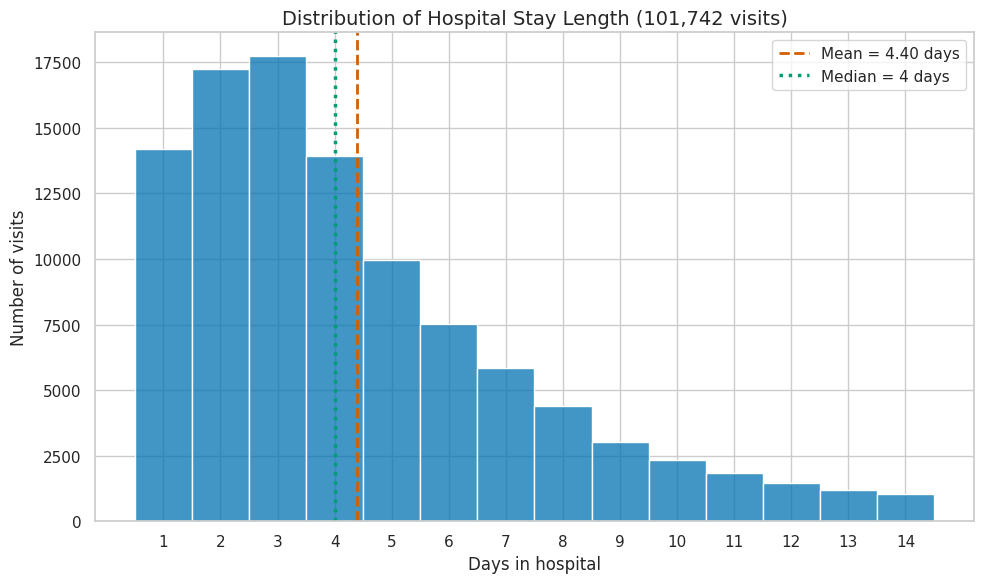

Stays of 1-4 days: 62.0%  |  1-6 days: 79.2%  |  10+ days: 7.8%
Most common stay length (mode): 3 days


In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
mean_days = df_clean["time_in_hospital"].mean()
median_days = df_clean["time_in_hospital"].median()

sns.histplot(df_clean["time_in_hospital"], bins=np.arange(0.5, 14.6, 1), color=palette[0], ax=ax)
ax.axvline(mean_days, color=palette[3], linestyle="--", linewidth=2, label=f"Mean = {mean_days:.2f} days")
ax.axvline(median_days, color=palette[2], linestyle=":", linewidth=2.5, label=f"Median = {median_days:.0f} days")
ax.set_title("Distribution of Hospital Stay Length (101,742 visits)", fontsize=14)
ax.set_xlabel("Days in hospital")
ax.set_ylabel("Number of visits")
ax.set_xticks(range(1, 15))
ax.legend()
save_fig(fig, "visualization_01_histogram_time_in_hospital.png")
plt.show()

stay = df_clean["time_in_hospital"]
print(f"Stays of 1-4 days: {(stay <= 4).mean()*100:.1f}%  |  1-6 days: {(stay <= 6).mean()*100:.1f}%  |  10+ days: {(stay >= 10).mean()*100:.1f}%")
print("Most common stay length (mode):", stay.mode().iloc[0], "days")

**What it shows:** The number of hospital visits for each stay length from 1 to 14 days, with the mean and median marked.

**Pattern:** The distribution is skewed to the right. The most common stay is 3 days (about 17,750 visits). 62.0% of stays last 1 to 4 days, 79.2% last 6 days or less, and only 7.8% last 10 days or more. The mean (4.40) sits to the right of the median (4) because the long tail of lengthy stays pulls the average up.

**What it means:** Most patients stay only a few days; a smaller group stays much longer. The dataset only contains stays between 1 and 14 days, so longer stays are not included.

**Why it matters:** The median describes a typical patient better than the mean here, and any planning based only on the average stay would slightly overestimate the typical case.

### Visualization 2 – Bar chart: readmission rate by earlier inpatient visits

Saved: images/visualization_02_bar_readmission_by_prior_visits.png


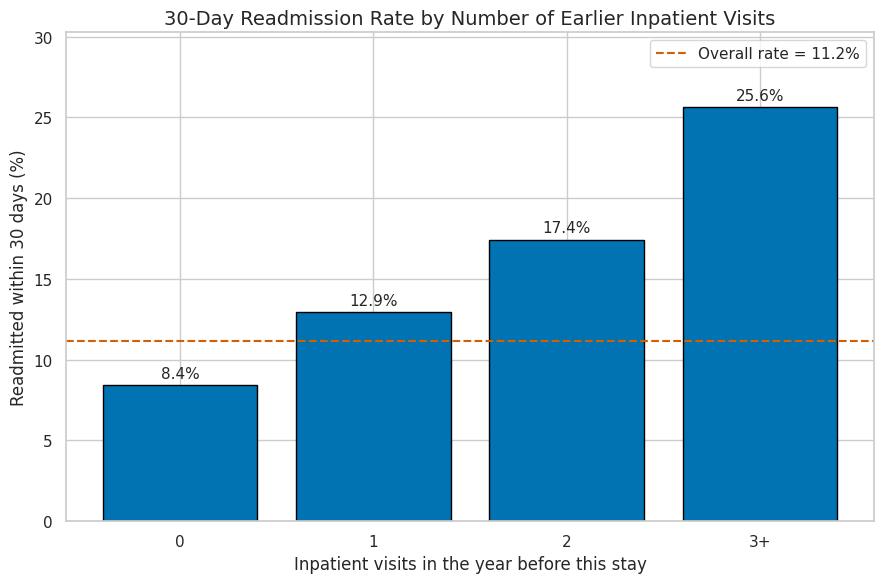

Patients per group: {'0': 67617, '1': 19515, '2': 7564, '3+': 7046}


In [42]:
order = ["0", "1", "2", "3+"]
rate_by_prior = (df_clean.groupby("prior_inpatient_group")["readmitted_30d"].mean() * 100).reindex(order)
counts_prior = df_clean["prior_inpatient_group"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(order, rate_by_prior.values, color=palette[0], edgecolor="black")
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in rate_by_prior.values], padding=3, fontsize=11)
ax.axhline(overall_rate, color=palette[3], linestyle="--", label=f"Overall rate = {overall_rate:.1f}%")
ax.set_title("30-Day Readmission Rate by Number of Earlier Inpatient Visits", fontsize=14)
ax.set_xlabel("Inpatient visits in the year before this stay")
ax.set_ylabel("Readmitted within 30 days (%)")
ax.set_ylim(0, rate_by_prior.max() * 1.18)
ax.legend()
save_fig(fig, "visualization_02_bar_readmission_by_prior_visits.png")
plt.show()

print("Patients per group:", counts_prior.to_dict())

**What it shows:** The percentage of visits that ended in a readmission within 30 days, grouped by how many inpatient visits the patient had in the previous year (0, 1, 2, or 3 and more). The dashed line is the overall rate (11.2%).

**Pattern:** The rate rises at every step: about 8.4% (67,617 visits) with no earlier inpatient visit, 12.9% (19,515) with one, 17.4% (7,564) with two, and 25.6% (7,046) with three or more. Only the first group is below the overall rate.

**What it means:** Patients with frequent recent hospital admissions are about three times as likely to return within 30 days as patients with none. This is an association, not proof of a cause, and because the same patients appear several times in the data the pattern may be partly inflated.

**Why it matters:** Previous admissions is the clearest warning sign for readmission in this dataset, and it is the strongest candidate variable for later prediction tasks.

### Visualization 3 – Pie chart: readmission outcome

Saved: images/visualization_03_pie_readmission_outcome.png


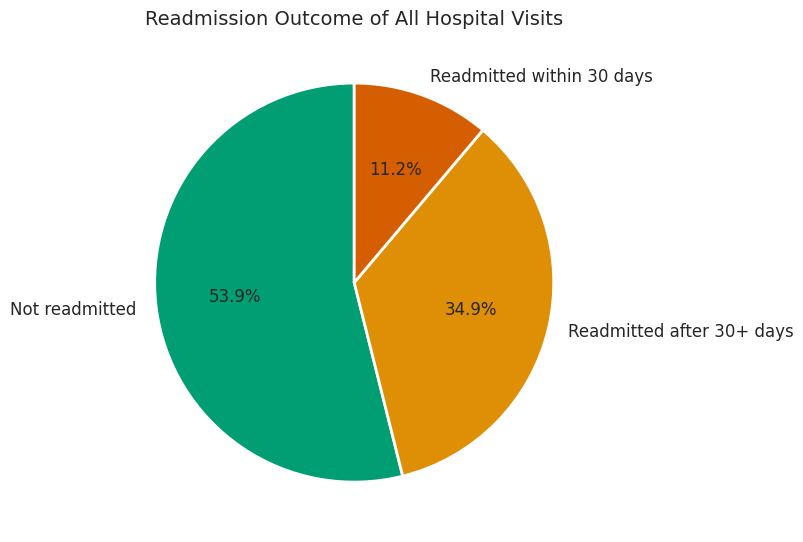

{'NO': 54849, '>30': 35541, '<30': 11352}


In [43]:
outcome_order = ["NO", ">30", "<30"]
outcome_labels = ["Not readmitted", "Readmitted after 30+ days", "Readmitted within 30 days"]
outcome_counts = df_clean["readmitted"].value_counts().reindex(outcome_order)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(outcome_counts.values, labels=outcome_labels, autopct="%1.1f%%", startangle=90,
       colors=[palette[2], palette[1], palette[3]], wedgeprops={"edgecolor": "white", "linewidth": 2},
       textprops={"fontsize": 12})
ax.set_title("Readmission Outcome of All Hospital Visits", fontsize=14)
save_fig(fig, "visualization_03_pie_readmission_outcome.png")
plt.show()

print(outcome_counts.to_dict())

**What it shows:** How all 101,742 visits are split between the three readmission outcomes.

**Pattern:** 53.9% (54,849 visits) were not readmitted, 34.9% (35,541) were readmitted after more than 30 days, and 11.2% (11,352) were readmitted within 30 days.

**What it means:** Most patients were not readmitted, and quick readmission within 30 days is the smallest group, about 1 visit in 9.

**Why it matters:** This is the baseline rate for every later comparison. It also shows the outcome is imbalanced (few early readmissions), which will matter if a prediction model is built later. That last point is my inference, not a tested result.

### Visualization 4 – Scatter plot: hospital stay vs number of medications

Saved: images/visualization_04_scatter_stay_vs_medications.png


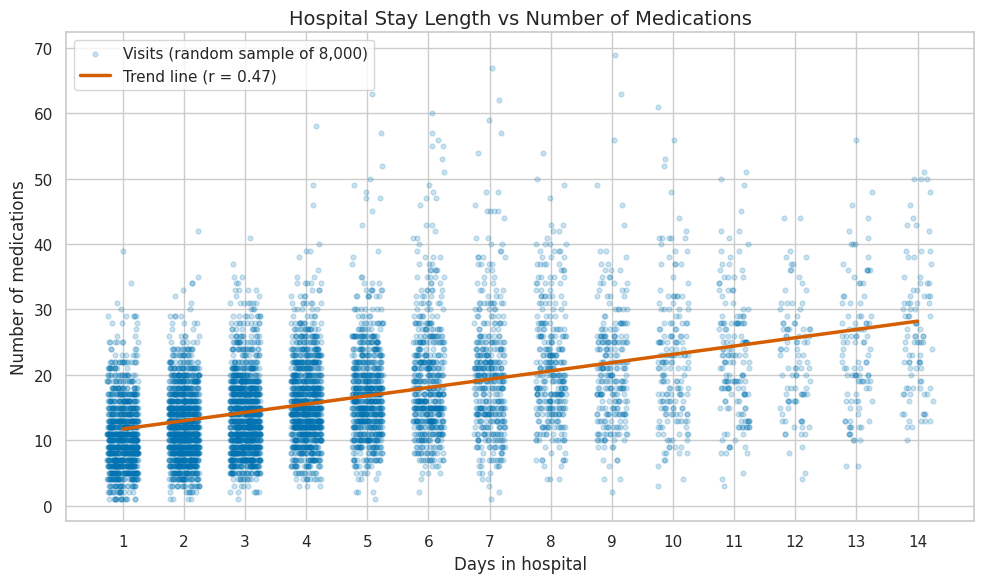

Correlation (all visits): 0.466   |  Trend: about 1.27 extra medications per extra day


In [44]:
rng = np.random.default_rng(42)
sample = df_clean.sample(8000, random_state=42)
jitter = rng.uniform(-0.25, 0.25, size=len(sample))   # days are whole numbers, so jitter spreads overlapping points

r_value = df_clean["time_in_hospital"].corr(df_clean["num_medications"])
slope, intercept = np.polyfit(df_clean["time_in_hospital"], df_clean["num_medications"], 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample["time_in_hospital"] + jitter, sample["num_medications"], alpha=0.2, s=12, color=palette[0],
           label="Visits (random sample of 8,000)")
xs = np.array([1, 14])
ax.plot(xs, slope * xs + intercept, color=palette[3], linewidth=2.5, label=f"Trend line (r = {r_value:.2f})")
ax.set_title("Hospital Stay Length vs Number of Medications", fontsize=14)
ax.set_xlabel("Days in hospital")
ax.set_ylabel("Number of medications")
ax.set_xticks(range(1, 15))
ax.legend(loc="upper left")
save_fig(fig, "visualization_04_scatter_stay_vs_medications.png")
plt.show()

print(f"Correlation (all visits): {r_value:.3f}   |  Trend: about {slope:.2f} extra medications per extra day")

**What it shows:** Each point is one hospital visit (a random sample of 8,000 is drawn so the chart stays readable, with a small horizontal shift so overlapping points can be seen). The line is the trend through all visits.

**Pattern:** The points drift upward: visits with longer stays tend to have more medications. The correlation is 0.47 and the trend adds about 1.27 medications per extra day. At every stay length the spread is wide, for example stays of 3 days range from about 2 to 40 medications, and a few visits have more than 60.

**What it means:** The relationship is positive and moderate, not strong: stay length explains only part of the medication count. It does not show that longer stays cause more medications; a likely explanation is that sicker patients both stay longer and need more treatment, but this data cannot test that.

**Why it matters:** It identifies the strongest link among the numeric variables and shows that treatment intensity (days, medications) moves together.

### Visualization 5 – Line chart: stay length and medications across age groups

Saved: images/visualization_05_line_trend_across_age.png


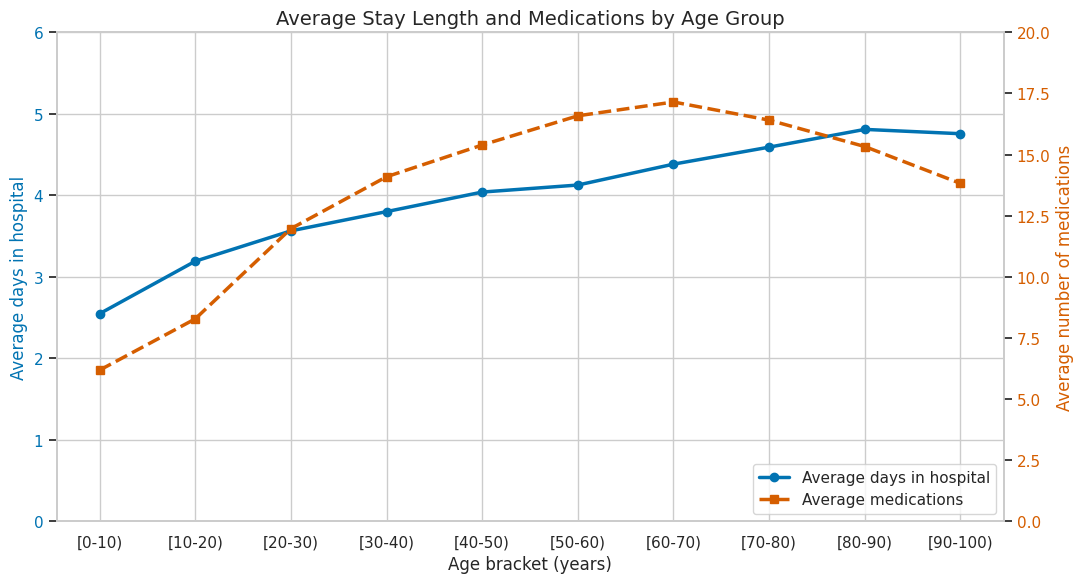

,avg_days,avg_meds
age,,
[0-10),2.55,6.18
[10-20),3.19,8.28
[20-30),3.56,11.97
[30-40),3.80,14.09
[40-50),4.04,15.39
[50-60),4.13,16.59
[60-70),4.38,17.15
[70-80),4.59,16.41
[80-90),4.81,15.33


In [45]:
by_age = df_clean.groupby("age", observed=True).agg(
    avg_days=("time_in_hospital", "mean"),
    avg_meds=("num_medications", "mean"))

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(by_age.index.astype(str), by_age["avg_days"], marker="o", color=palette[0], linewidth=2.5, label="Average days in hospital")
ax1.set_xlabel("Age bracket (years)")
ax1.set_ylabel("Average days in hospital", color=palette[0])
ax1.tick_params(axis="y", labelcolor=palette[0])
ax1.set_ylim(0, 6)

ax2 = ax1.twinx()
ax2.plot(by_age.index.astype(str), by_age["avg_meds"], marker="s", color=palette[3], linewidth=2.5, linestyle="--", label="Average medications")
ax2.set_ylabel("Average number of medications", color=palette[3])
ax2.tick_params(axis="y", labelcolor=palette[3])
ax2.set_ylim(0, 20)
ax2.grid(False)

ax1.set_title("Average Stay Length and Medications by Age Group", fontsize=14)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="lower right")
save_fig(fig, "visualization_05_line_trend_across_age.png")
plt.show()

display(by_age.round(2))

**What it shows:** The average hospital stay (solid line, left axis) and the average number of medications (dashed line, right axis) for each age bracket. The dataset has no date column, so this line chart shows the trend across age groups, not across time.

**Pattern:** The average stay rises from 2.55 days for ages 0 to 10 to 4.81 days for ages 80 to 90 (4.76 for 90 and over). The average number of medications rises from 6.18 to a peak of 17.15 at ages 60 to 70, then falls to 13.82 at ages 90 to 100.

**What it means:** Older patients tend to stay longer, but the medication count does not keep rising: it peaks in the 60s and declines in the oldest groups. The reason is not shown by this data. The two lines use different vertical scales, so the point where they cross has no meaning.

**Why it matters:** Age is related to hospital use, and its effect is not a simple straight line, which is useful to know before building any model.

### Visualization 6 – Box plot: medications by medication change

Saved: images/visualization_06_box_medications_by_change.png


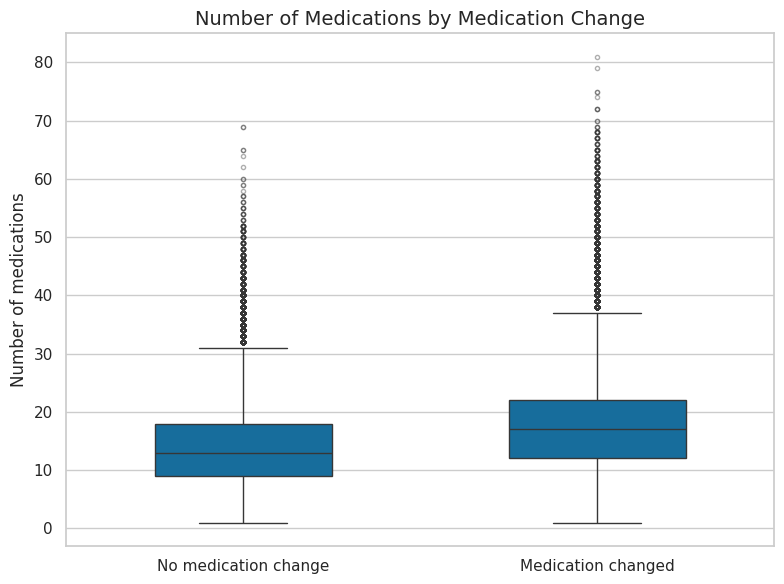

          count   mean   25%   50%   75%   max
change                                        
Ch      47001.0  18.19  12.0  17.0  22.0  81.0
No      54741.0  14.16   9.0  13.0  18.0  69.0


In [46]:
box_order = ["No", "Ch"]
box_labels = ["No medication change", "Medication changed"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df_clean, x="change", y="num_medications", order=box_order, color=palette[0], width=0.5,
            flierprops={"markersize": 3, "alpha": 0.4}, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(box_labels)
ax.set_title("Number of Medications by Medication Change", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Number of medications")
save_fig(fig, "visualization_06_box_medications_by_change.png")
plt.show()

print(df_clean.groupby("change", observed=True)["num_medications"].describe()[["count", "mean", "25%", "50%", "75%", "max"]].round(2))

**What it shows:** The distribution of the number of medications for visits where diabetes medication was changed and visits where it was not. The box shows the middle 50% of visits, the line inside is the median, and the dots are unusually high values.

**Pattern:** Visits with a medication change have a higher median (17 vs 13) and a higher middle range (12 to 22 vs 9 to 18). Both groups have a long upper tail, with maximums of 81 and 69 medications.

**What it means:** Visits where medication was changed involve more medications overall. Both groups have many high values, which Part 3.8 showed are plausible long and complex stays, so they were kept. This is an association; the data cannot say whether changing medication leads to more medications or whether complicated cases lead to both.

**Why it matters:** It shows that a medication change marks more complex visits, which is useful context for the readmission differences seen in Part 3.7.

### Visualization 7 – Correlation heatmap

Saved: images/visualization_07_heatmap_correlation.png


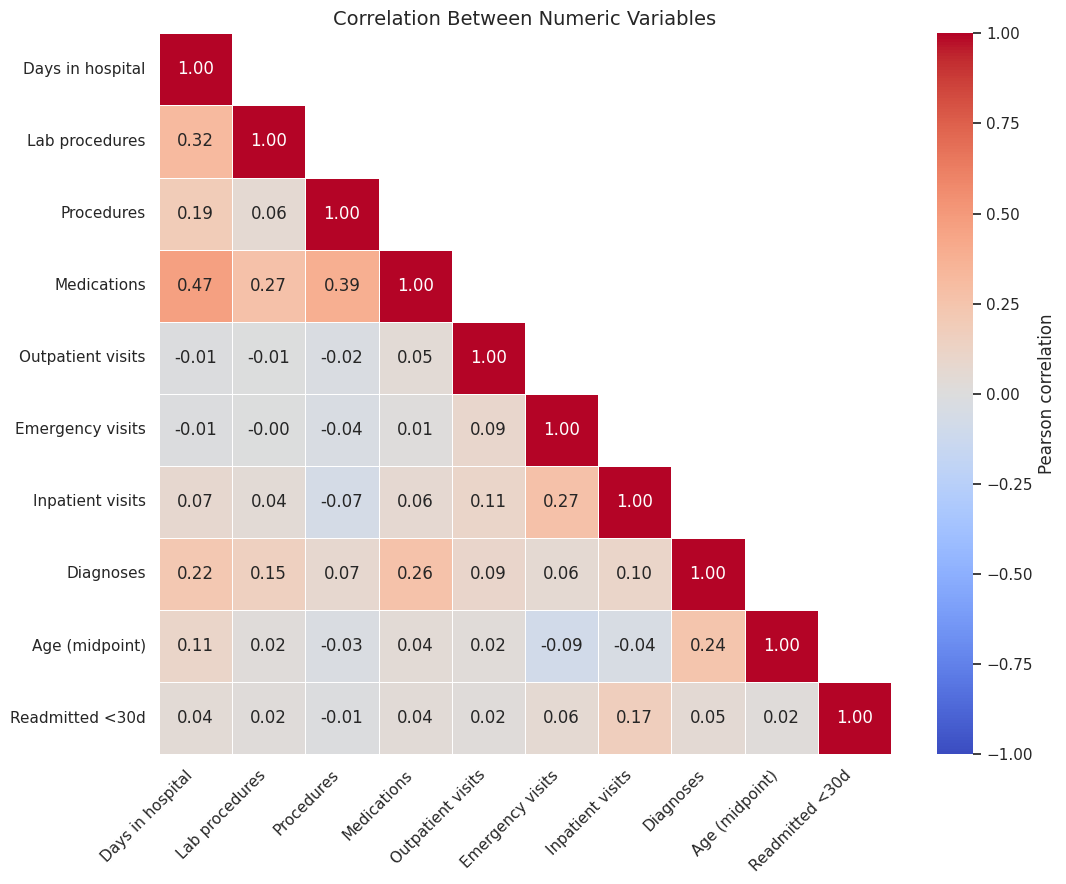

In [47]:
heat_cols = num_cols + ["age_midpoint", "readmitted_30d"]
heat_labels = ["Days in hospital", "Lab procedures", "Procedures", "Medications", "Outpatient visits",
               "Emergency visits", "Inpatient visits", "Diagnoses", "Age (midpoint)", "Readmitted <30d"]
corr_matrix = df_clean[heat_cols].corr()
corr_matrix.index = heat_labels
corr_matrix.columns = heat_labels
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # hide the duplicate upper triangle

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0,
            linewidths=0.5, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation Between Numeric Variables", fontsize=14)
ax.grid(False)
plt.xticks(rotation=45, ha="right")
save_fig(fig, "visualization_07_heatmap_correlation.png")
plt.show()

**What it shows:** The correlation between every pair of numeric variables, plus age and 30-day readmission. Values near 0 mean no straight-line relationship; the colour shows strength and direction. The repeated upper half is hidden.

**Pattern:** The strongest relationships are days in hospital with medications (0.47), procedures with medications (0.39), days with lab procedures (0.32), emergency with inpatient visits (0.27), medications with diagnoses (0.26) and age with diagnoses (0.24). The visit-count variables are almost unrelated to the stay measures (between -0.04 and 0.05). For 30-day readmission the highest value is inpatient visits (0.17); all others are 0.06 or lower.

**What it means:** No pair is strongly correlated (none above 0.5), so no variable is a near-copy of another. Stay, medications, procedures and lab tests form a loosely connected group. Readmission has only weak straight-line links with these numeric variables.

**Why it matters:** Weak correlations with readmission mean no single numeric variable predicts it well. This is an inference for later tasks; Pearson correlation only measures straight-line relationships, so it can miss other patterns.

### Visualization 8 – Count plot: visits by age bracket

Saved: images/visualization_08_countplot_age.png


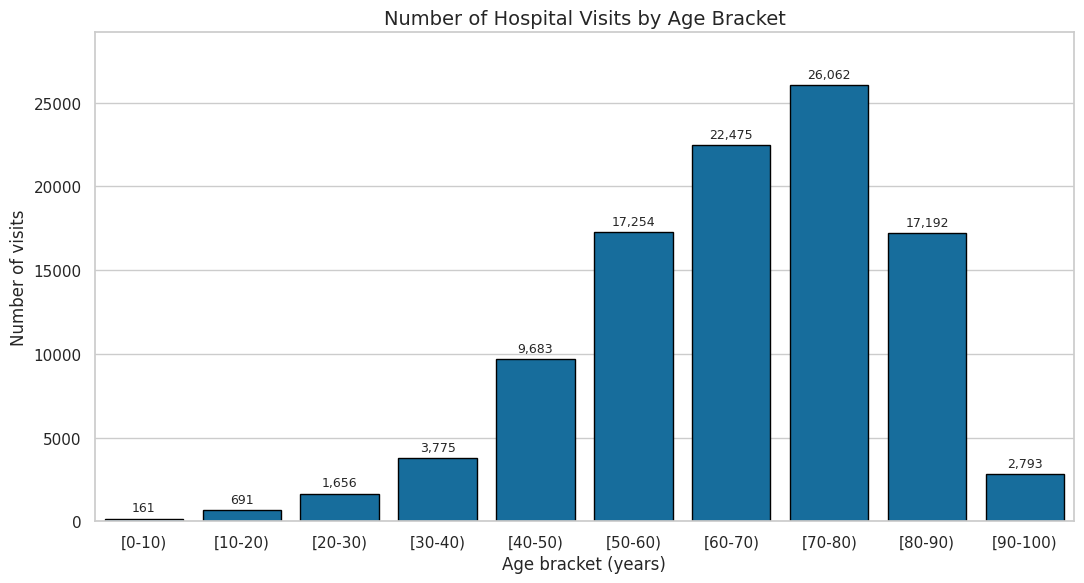

Share of visits by age bracket (%):
age
[0-10)       0.2
[10-20)      0.7
[20-30)      1.6
[30-40)      3.7
[40-50)      9.5
[50-60)     17.0
[60-70)     22.1
[70-80)     25.6
[80-90)     16.9
[90-100)     2.7
Ages 50-89 combined: 81.6%  |  under 40: 6.2%


In [48]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.countplot(data=df_clean, x="age", order=age_order, color=palette[0], edgecolor="black", ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3, fontsize=9)
ax.set_title("Number of Hospital Visits by Age Bracket", fontsize=14)
ax.set_xlabel("Age bracket (years)")
ax.set_ylabel("Number of visits")
ax.set_ylim(0, df_clean["age"].value_counts().max() * 1.12)
save_fig(fig, "visualization_08_countplot_age.png")
plt.show()

age_share = (df_clean["age"].value_counts(normalize=True) * 100).round(1)
print("Share of visits by age bracket (%):")
print(age_share.sort_index().to_string())
print(f"Ages 50-89 combined: {age_share[['[50-60)','[60-70)','[70-80)','[80-90)']].sum():.1f}%  |  under 40: {age_share[['[0-10)','[10-20)','[20-30)','[30-40)']].sum():.1f}%")

**What it shows:** The number of visits in each age bracket.

**Pattern:** The distribution peaks at ages 70 to 80 (26,062 visits, 25.6%). Ages 50 to 89 together make up 81.6% of all visits, while under 40 makes up only 6.2% (for example 161 visits at ages 0 to 10).

**What it means:** The patients in this dataset are mainly older adults.

**Why it matters:** Conclusions apply mostly to older patients. Rates for the youngest groups are based on very few patients and should be treated carefully, for example the 1.86% readmission rate at ages 0 to 10 comes from 161 visits.

### Visualization 9 – Pair plot: main numeric variables

Saved: images/visualization_09_pairplot_numeric.png


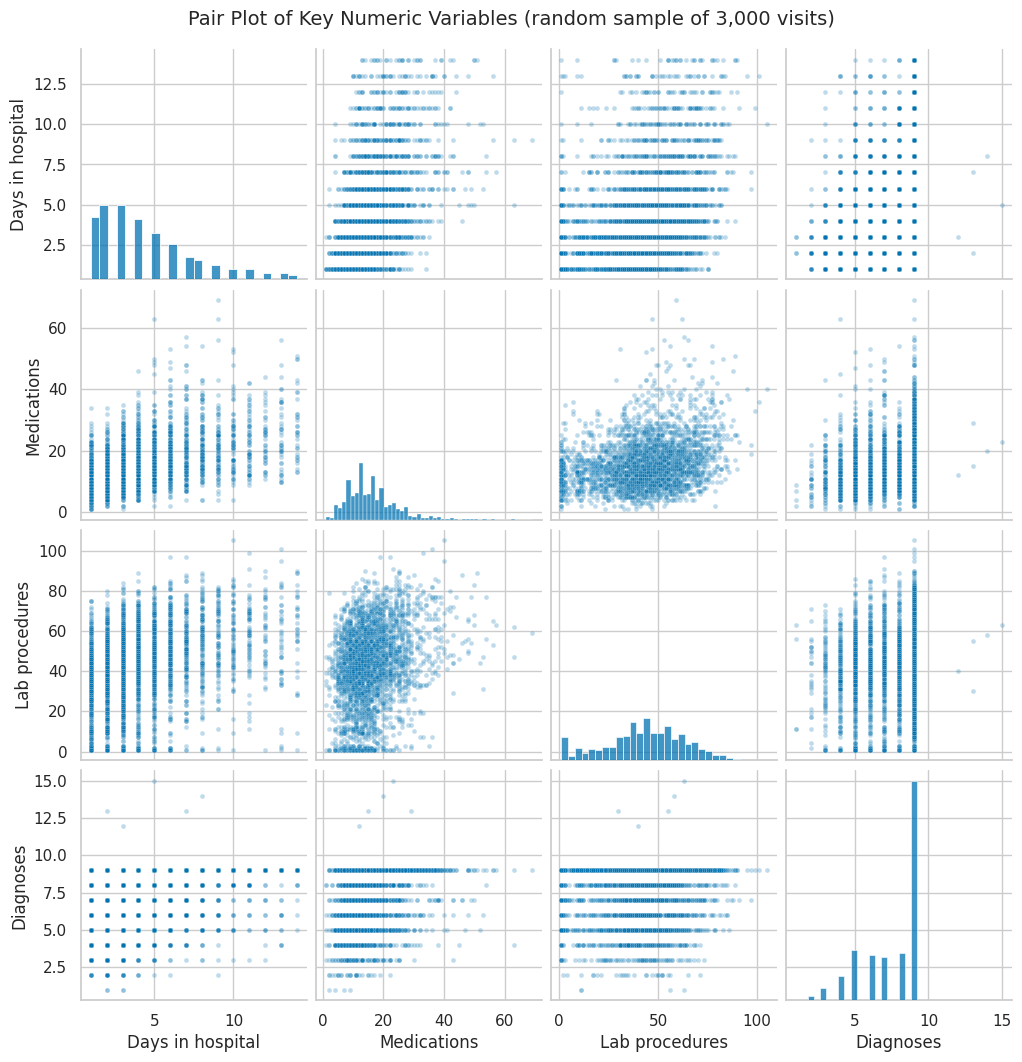

In [49]:
pair_cols = ["time_in_hospital", "num_medications", "num_lab_procedures", "number_diagnoses"]
pair_sample = df_clean[pair_cols].sample(3000, random_state=42)
pair_sample.columns = ["Days in hospital", "Medications", "Lab procedures", "Diagnoses"]

g = sns.pairplot(pair_sample, diag_kind="hist", plot_kws={"alpha": 0.25, "s": 12, "color": palette[0]},
                 diag_kws={"color": palette[0]}, height=2.6)
g.figure.suptitle("Pair Plot of Key Numeric Variables (random sample of 3,000 visits)", y=1.02, fontsize=14)
g.savefig(IMAGES_DIR / "visualization_09_pairplot_numeric.png", dpi=150, bbox_inches="tight")
print("Saved:", IMAGES_DIR / "visualization_09_pairplot_numeric.png")
plt.show()

**What it shows:** Scatter plots for every pair of four key variables (days in hospital, medications, lab procedures, diagnoses), with the distribution of each variable on the diagonal. A random sample of 3,000 visits is used for readability.

**Pattern:** Days in hospital is skewed to the right and medications are roughly bell-shaped around 15 with a right tail. Lab procedures spread widely with a visible group at very low values. Diagnoses pile up at 9. The medications versus days panel shows the upward drift seen in Visualization 4, while the other pairs show only loose clouds.

**What it means:** Apart from stay and medications, the variables are only weakly connected. The pile-up at 9 diagnoses is notable: 48.6% of all visits have exactly 9 diagnoses, which may mean a limit in how diagnoses were recorded. This is a possibility I did not verify.

**Why it matters:** It gives a quick overview of all relationships at once and reveals data features (like the cap at 9) that single statistics would hide.

### Visualization 10 – Violin plot: number of diagnoses by age group

Saved: images/visualization_10_violin_diagnoses_by_age.png


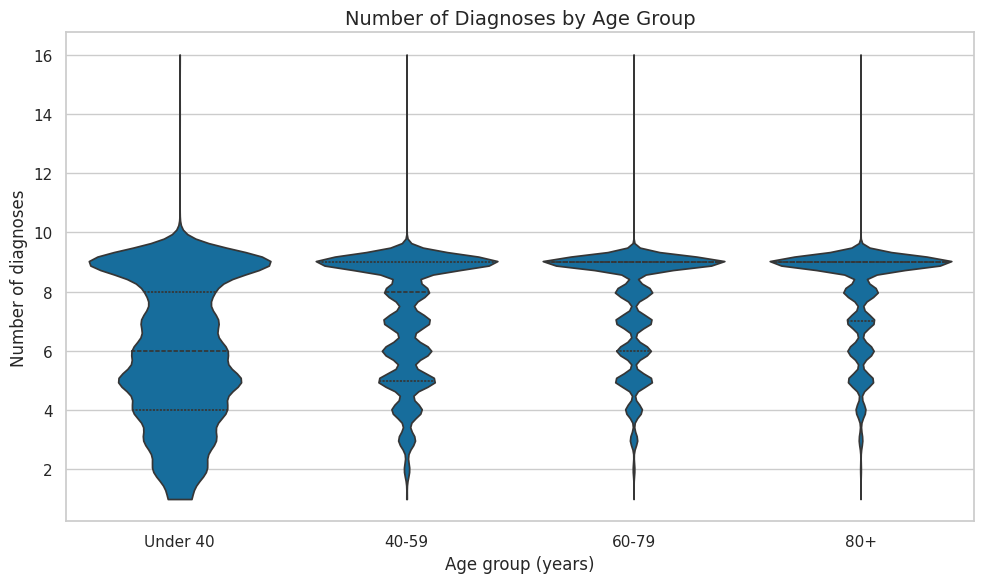

             count  mean  25%  50%  75%   max
age_group                                    
Under 40    6283.0  5.93  4.0  6.0  8.0  16.0
40-59      26937.0  7.13  5.0  8.0  9.0  16.0
60-79      48537.0  7.58  6.0  9.0  9.0  16.0
80+        19985.0  7.89  7.0  9.0  9.0  16.0
Share of visits with exactly 9 diagnoses: 48.6%


In [50]:
age_group_order = ["Under 40", "40-59", "60-79", "80+"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_clean, x="age_group", y="number_diagnoses", order=age_group_order, color=palette[0],
               cut=0, inner="quartile", density_norm="width", ax=ax)   # same maximum width for every violin
ax.set_title("Number of Diagnoses by Age Group", fontsize=14)
ax.set_xlabel("Age group (years)")
ax.set_ylabel("Number of diagnoses")
save_fig(fig, "visualization_10_violin_diagnoses_by_age.png")
plt.show()

print(df_clean.groupby("age_group", observed=True)["number_diagnoses"].describe()[["count", "mean", "25%", "50%", "75%", "max"]].round(2))
print("Share of visits with exactly 9 diagnoses: {:.1f}%".format((df_clean["number_diagnoses"] == 9).mean() * 100))

**What it shows:** The spread of the number of diagnoses within four age groups. A wider part means more visits at that value, and the dotted lines mark the quartiles (25%, 50%, 75%).

**Pattern:** The median number of diagnoses rises from 6 (under 40) to 8 (ages 40 to 59) and 9 (ages 60 to 79 and 80 and over); the means are 5.93, 7.13, 7.58 and 7.89. The youngest group is spread over many values, while the older groups are concentrated at 9. The wiggles appear because the data are whole numbers, and the thin line up to 16 represents a very small number of visits.

**What it means:** Older patients are recorded with more diagnoses. The older groups look similar partly because 48.6% of all visits sit at exactly 9, so the differences between them are compressed.

**Why it matters:** It supports the correlation of 0.24 between age and diagnoses, and shows the difference is mainly between younger and older patients.

### Visualization 11 (extra) – Bar chart: readmission rate by medical specialty

Saved: images/visualization_11_bar_readmission_by_specialty.png


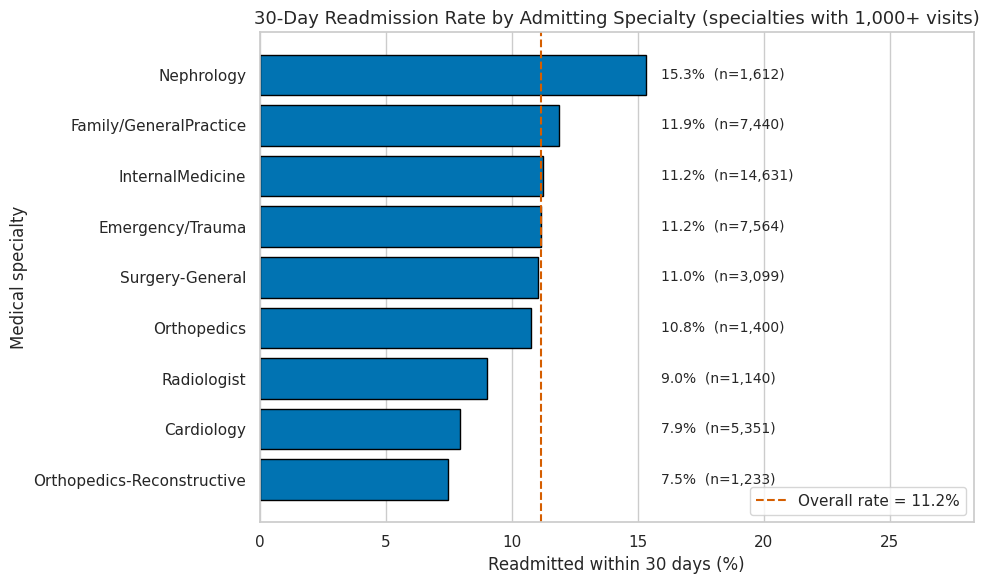

In [51]:
spec_rate = (df_clean.groupby("medical_specialty", observed=True)
             .agg(patients=("readmitted_30d", "size"), rate=("readmitted_30d", lambda s: s.mean() * 100)))
spec_rate = spec_rate[(spec_rate["patients"] >= 1000)].drop(index="Unknown", errors="ignore").sort_values("rate")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(spec_rate.index.astype(str), spec_rate["rate"], color=palette[0], edgecolor="black")
label_x = spec_rate["rate"].max() * 1.04          # labels in one column on the right, clear of the overall-rate line
for i, (rate, n) in enumerate(zip(spec_rate["rate"], spec_rate["patients"])):
    ax.text(label_x, i, f"{rate:.1f}%  (n={n:,})", va="center", fontsize=10)
ax.axvline(overall_rate, color=palette[3], linestyle="--", label=f"Overall rate = {overall_rate:.1f}%")
ax.set_title("30-Day Readmission Rate by Admitting Specialty (specialties with 1,000+ visits)", fontsize=13)
ax.set_xlabel("Readmitted within 30 days (%)")
ax.set_ylabel("Medical specialty")
ax.set_xlim(0, spec_rate["rate"].max() * 1.85)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
save_fig(fig, "visualization_11_bar_readmission_by_specialty.png")
plt.show()

**What it shows:** The 30-day readmission rate for each admitting specialty with at least 1,000 visits. The dashed line is the overall rate (11.2%) and n is the number of visits.

**Pattern:** Nephrology is highest (15.3%, 1,612 visits). Family/General Practice (11.9%), Internal Medicine (11.2%) and Emergency/Trauma (11.2%) are close to the overall rate. Cardiology (7.9%, 5,351 visits) and Orthopedics-Reconstructive (7.5%, 1,233 visits) are lowest.

**What it means:** Readmission differs between specialties, but only 9 specialties qualify and about half of all visits have an unknown specialty, so this covers only part of the data. The differences most likely reflect different kinds of patients, not the quality of care; a possible explanation for Nephrology is more seriously ill patients, which was not tested.

**Why it matters:** It shows where readmissions concentrate, and shows why the specialty field would need better data before it could be used for firm conclusions.

### Saved images

In [52]:
saved = sorted(p.name for p in IMAGES_DIR.glob("visualization_*.png"))
print(f"{len(saved)} images saved in {IMAGES_DIR}:")
for name in saved:
    print(" -", name)

# Google Colab only: bundle the images so they can be downloaded and added to the GitHub repo
try:
    import shutil
    from google.colab import files
    shutil.make_archive("images", "zip", IMAGES_DIR)
    files.download("images.zip")
except ImportError:
    pass   # running locally - images are already in the images folder

11 images saved in images:
 - visualization_01_histogram_time_in_hospital.png
 - visualization_02_bar_readmission_by_prior_visits.png
 - visualization_03_pie_readmission_outcome.png
 - visualization_04_scatter_stay_vs_medications.png
 - visualization_05_line_trend_across_age.png
 - visualization_06_box_medications_by_change.png
 - visualization_07_heatmap_correlation.png
 - visualization_08_countplot_age.png
 - visualization_09_pairplot_numeric.png
 - visualization_10_violin_diagnoses_by_age.png
 - visualization_11_bar_readmission_by_specialty.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Part 4 Summary
- **11 charts created and saved** in `images/` (the 10 required types plus one extra): histogram, bar, pie, scatter, line, box, correlation heatmap, count plot, pair plot, violin, and a specialty bar chart.
- **Stay length** is right-skewed: most stays are 1 to 4 days (62.0%).
- **Earlier inpatient visits** show the clearest pattern: readmission within 30 days rises from about 8.4% to 25.6%.
- **Stay and medications** are moderately related (r = 0.47); no pair of numeric variables is strongly correlated.
- **Age:** the dataset is mostly older adults (ages 50 to 89 make up 81.6%); stay length rises with age while medications peak at ages 60 to 70.
- **Data features worth noting:** 48.6% of visits have exactly 9 diagnoses, and about half of the specialty values are unknown.
- **Limits:** all findings are associations; the line chart is across age, not time; repeated patients and unverified code columns remain limitations.

---
## PART 5 – Data Insights & Findings

Every insight below comes from the results in Parts 2 to 4 of this notebook. The cell below recalculates every number used, so each insight can be traced back to the data. All insights describe **associations in this dataset**, not causes.

In [53]:
# Every number used in the insights below is recalculated here, so each insight can be traced to the data
stay = df_clean["time_in_hospital"]
rate_prior = (df_clean.groupby("prior_inpatient_group")["readmitted_30d"].mean() * 100).round(2)
by_age_stats = df_clean.groupby("age", observed=True).agg(days=("time_in_hospital", "mean"), meds=("num_medications", "mean")).round(2)
tested = df_clean["a1c_result"] != "Not tested"
spec_tbl = (df_clean.groupby("medical_specialty", observed=True)
            .agg(n=("readmitted_30d", "size"), rate=("readmitted_30d", lambda s: s.mean() * 100)))
spec_tbl = spec_tbl[spec_tbl["n"] >= 1000].drop(index="Unknown", errors="ignore")
age_share = df_clean["age"].value_counts(normalize=True) * 100
top_emerg = df_clean.nlargest(5, "number_emergency")["patient_id"].nunique()
cv = df_clean[num_cols].std() / df_clean[num_cols].mean()
gender_rate = (df_clean.groupby("gender", observed=True)["readmitted_30d"].mean() * 100).round(2)
change_rate = (df_clean.groupby("change", observed=True)["readmitted_30d"].mean() * 100).round(2)
meds_median = df_clean.groupby("change", observed=True)["num_medications"].median()

def plain(v):
    """Convert numpy numbers to plain Python numbers so the printout is easy to read"""
    if isinstance(v, tuple):
        return tuple(plain(x) for x in v)
    if isinstance(v, dict):
        return {k: plain(x) for k, x in v.items()}
    if isinstance(v, (np.floating, np.integer)):
        return v.item()
    return v

facts = {
    "Visits analysed": len(df_clean),
    "Overall 30-day readmission rate (%)": round(overall_rate, 2),
    "Not readmitted at all (%)": round((df_clean["readmitted"] == "NO").mean() * 100, 1),
    "Stays of 1-4 days (%)": round((stay <= 4).mean() * 100, 1),
    "Mean / median stay (days)": (round(stay.mean(), 2), stay.median()),
    "Readmission rate by earlier inpatient visits (%)": rate_prior.to_dict(),
    "Correlation days vs medications": round(df_clean["time_in_hospital"].corr(df_clean["num_medications"]), 3),
    "Correlation inpatient visits vs 30-day readmission": round(df_clean["number_inpatient"].corr(df_clean["readmitted_30d"]), 3),
    "Average stay: ages 0-10 / 80-90 (days)": (by_age_stats.loc["[0-10)", "days"], by_age_stats.loc["[80-90)", "days"]),
    "Average medications: peak bracket / value": (by_age_stats["meds"].idxmax(), by_age_stats["meds"].max()),
    "Median medications: no change / changed": (meds_median["No"], meds_median["Ch"]),
    "Readmission rate: no change / changed (%)": (change_rate["No"], change_rate["Ch"]),
    "Visits aged 50-89 (%)": round(age_share[["[50-60)", "[60-70)", "[70-80)", "[80-90)"]].sum(), 1),
    "HbA1c not tested (%)": round((~tested).mean() * 100, 1),
    "Readmission: HbA1c not tested / tested (%)": (round(df_clean.loc[~tested, "readmitted_30d"].mean() * 100, 2),
                                                   round(df_clean.loc[tested, "readmitted_30d"].mean() * 100, 2)),
    "Specialties with 1,000+ visits": len(spec_tbl),
    "Highest specialty (rate %, visits)": (spec_tbl["rate"].idxmax(), round(spec_tbl["rate"].max(), 2), int(spec_tbl.loc[spec_tbl["rate"].idxmax(), "n"])),
    "Lowest specialty (rate %, visits)": (spec_tbl["rate"].idxmin(), round(spec_tbl["rate"].min(), 2), int(spec_tbl.loc[spec_tbl["rate"].idxmin(), "n"])),
    "Specialty unknown (%)": round((df_clean["medical_specialty"] == "Unknown").mean() * 100, 1),
    "Highest / lowest coefficient of variation": (cv.idxmax(), round(cv.max(), 2), cv.idxmin(), round(cv.min(), 2)),
    "Distinct patients among the 5 highest emergency counts": top_emerg,
    "Visits with exactly 9 diagnoses (%)": round((df_clean["number_diagnoses"] == 9).mean() * 100, 1),
    "Readmission rate by gender (%)": gender_rate.to_dict(),
    "Hidden '?' cells converted in Part 2": int(cleaning_log[0]["affected"]),
}
for key, value in facts.items():
    print(f"{key}: {plain(value)}")

Visits analysed: 101742
Overall 30-day readmission rate (%): 11.16
Not readmitted at all (%): 53.9
Stays of 1-4 days (%): 62.0
Mean / median stay (days): (4.4, 4.0)
Readmission rate by earlier inpatient visits (%): {'0': 8.44, '1': 12.92, '2': 17.44, '3+': 25.65}
Correlation days vs medications: 0.466
Correlation inpatient visits vs 30-day readmission: 0.165
Average stay: ages 0-10 / 80-90 (days): (2.55, 4.81)
Average medications: peak bracket / value: ('[60-70)', 17.15)
Median medications: no change / changed: (13.0, 17.0)
Readmission rate: no change / changed (%): (10.59, 11.82)
Visits aged 50-89 (%): 81.6
HbA1c not tested (%): 83.3
Readmission: HbA1c not tested / tested (%): (11.42, 9.84)
Specialties with 1,000+ visits: 9
Highest specialty (rate %, visits): ('Nephrology', 15.32, 1612)
Lowest specialty (rate %, visits): ('Orthopedics-Reconstructive', 7.46, 1233)
Specialty unknown (%): 49.1
Highest / lowest coefficient of variation: ('number_emergency', 4.7, 'number_diagnoses', 0.26)


### 5.1 Ten-plus Insights

**Insight 1 – Most hospital stays are short, and the average is pulled up by a few long ones.**
62.0% of stays last 1 to 4 days; the mean is 4.40 days but the median is 4. *Evidence:* Visualization 1, section 3.3. *Meaning:* the median describes a typical patient better than the mean.

**Insight 2 – The number of earlier inpatient visits is the clearest warning sign for early readmission.**
The 30-day readmission rate rises from 8.44% (no earlier visit) to 12.92%, 17.44% and 25.65% (three or more), roughly three times higher. *Evidence:* Visualization 2, section 3.7. *Caution:* an association, and repeated patients may inflate it.

**Insight 3 – Quick readmission is the minority outcome, but not rare.**
53.9% of visits were never followed by a readmission, and 11.16% were followed by one within 30 days (about 1 in 9). *Evidence:* Visualization 3. *Meaning:* this is the baseline for every comparison, and the outcome is imbalanced.

**Insight 4 – Longer stays go together with more medications (moderate positive relationship).**
The correlation is 0.47, about 1.27 more medications per extra day. It is the strongest correlation among all numeric pairs. *Evidence:* Visualizations 4 and 7. *Caution:* sicker patients likely drive both; the data cannot show cause.

**Insight 5 – Stay length rises with age, but medications peak at ages 60 to 70.**
The average stay grows from 2.55 days (ages 0 to 10) to 4.81 days (80 to 90). The average number of medications peaks at 17.15 for ages 60 to 70, then declines. *Evidence:* Visualization 5. *Meaning:* the effect of age is not a simple straight line.

**Insight 6 – Visits with a medication change are more complex.**
The median number of medications is 17 with a medication change and 13 without; the readmission rate is also higher (11.82% vs 10.59%). *Evidence:* Visualization 6, section 3.7. *Caution:* the difference in readmission is small and may reflect sicker patients, not the change itself.

**Insight 7 – The patients are mostly older adults.**
81.6% of visits are for ages 50 to 89, and only 161 visits are for ages 0 to 10. *Evidence:* Visualization 8. *Meaning:* findings mainly apply to older patients, and results for the youngest groups are unreliable.

**Insight 8 – No numeric variable is strongly related to readmission.**
The highest correlation with 30-day readmission is 0.165 (earlier inpatient visits); all others are 0.06 or lower, and no pair of variables exceeds 0.5. *Evidence:* Visualization 7, section 3.6. *Meaning:* readmission does not follow a simple straight-line link with these numbers; this is relevant for later prediction tasks.

**Insight 9 – Readmission differs by specialty, but the specialty data is incomplete.**
Nephrology has the highest rate (15.32%, 1,612 visits) and Orthopedics-Reconstructive the lowest (7.46%, 1,233 visits), but only 9 specialties have 1,000 or more visits and 49.1% of visits have an unknown specialty. *Evidence:* Visualization 11. *Caution:* differences likely reflect patient mix, not quality of care.

**Insight 10 – Most patients had no HbA1c test, and those tested were readmitted less often.**
83.3% of visits have no HbA1c test. The readmission rate was 11.42% without the test and 9.84% with it. *Evidence:* section 3.7. *Caution:* an association only; patients who get tested may differ from those who do not.

**Insight 11 – Previous-visit counts vary hugely, and one patient drives the extreme values.**
The coefficient of variation of `number_emergency` is 4.70, the highest of all variables, and the five largest values (46 to 76) all belong to one patient. *Evidence:* sections 3.5 and 3.8. *Meaning:* extreme values are real records but not typical, and repeated patients affect the statistics.

**Insight 12 – Nearly half of all visits have exactly 9 diagnoses.**
48.6% of visits have 9 diagnoses, while the maximum is 16. *Evidence:* Visualizations 9 and 10. *Meaning:* this looks like a ceiling in how diagnoses were recorded (my inference, not verified), and it makes differences between age groups appear smaller.

**Insight 13 – Gender makes almost no difference to readmission.**
The rate is 11.24% for females and 11.06% for males. *Evidence:* section 3.7. *Meaning:* gender is not an important factor in this dataset.

**Insight 14 – The raw data hid a large amount of missing information.**
192,849 cells held `?` placeholders that pandas did not count as missing, and `weight` was missing in 96.86% of rows. *Evidence:* Parts 1 and 2. *Meaning:* checking for hidden missing values changed the analysis; without it, the dataset would have appeared complete.

### 5.2 Answers to the Guiding Questions

| Question | Answer from this dataset |
|---|---|
| Which feature has the strongest relationship with an important variable? | Stay length with medications (r = 0.47). For readmission, earlier inpatient visits (r = 0.165; rate 8.44% to 25.65%) |
| Which category has the highest average value? | Highest readmission: three or more earlier inpatient visits (25.65%). Among specialties: Nephrology (15.32%, and the longest average stay at 5.02 days) |
| Which category has the lowest average value? | No earlier inpatient visit (8.44%); Orthopedics-Reconstructive (7.46%) among specialties; ages 0 to 10 have the shortest stay (2.55 days) |
| What is the most common category? | Caucasian (74.8%), female (53.8%), age 70 to 80 (25.6%), not readmitted (53.9%), primary diagnosis code 428 (6.7%) |
| Are there significant outliers? | Yes: up to 81 medications, 132 lab procedures and 76 emergency visits. They are plausible and were kept; the largest emergency counts come from one patient |
| Is there a positive or negative relationship? | Positive: stay with medications (0.47). Negative relationships exist but are very weak, for example age with emergency visits (-0.09) |
| Which variable has the greatest variation? | Relative to its mean: `number_emergency` (coefficient of variation 4.70). In raw units: `num_lab_procedures` (standard deviation 19.67) |
| What major trend can be observed? | Stay length rises with age, and readmission rises with the number of earlier inpatient visits |
| What unusual pattern was discovered? | 48.6% of visits have exactly 9 diagnoses; one patient has the five highest emergency counts; 83.3% of visits have no HbA1c test |
| What conclusion can be drawn overall? | See Part 6 |
| Possible real-world usefulness | Hospitals could pay closer attention to patients with several recent admissions when planning follow-up (an implication of the pattern, not a tested intervention), and better recording of specialty, payer and weight would improve future analyses |

*All of these are associations in this dataset. They do not prove that one variable causes another.*

---
## PART 6 – Final Conclusion

For this task I analysed the *Diabetes 130-US Hospitals for Years 1999-2008* dataset from Kaggle, which describes 101,766 hospital visits by patients with diabetes and records whether each patient was readmitted. I loaded the data, checked its structure and found that 192,849 cells held hidden `?` placeholders that pandas does not count as missing. I cleaned the data by converting these placeholders, dropping the almost-empty `weight` column, labelling unknown categories, removing 24 rows (0.024%) with no primary diagnosis or an invalid gender, converting codes and age brackets to proper categories, and renaming 12 columns. Each decision was recorded in a cleaning log. I then calculated the mean, median, mode, range, standard deviation, variance and correlations, compared groups, and created 11 visualizations, each with a written interpretation.

The most important findings are that most hospital stays are short (62.0% last 1 to 4 days), that 11.16% of visits ended in a readmission within 30 days, and that the number of earlier inpatient visits is the clearest pattern: the readmission rate rises from 8.44% to 25.65%. Stay length and medications are moderately related (r = 0.47), but no numeric variable is strongly related to readmission. These results are associations, not causes, and have limits: some patients appear many times, the meaning of some code columns was not checked, and about half of the specialty values are unknown. From this project I learned to check for hidden missing values and verify the data after loading, to choose the median when values are skewed, to explain every cleaning decision, and to describe results carefully instead of claiming causes. The analysis suggests that hospitals could give extra attention to patients with several recent admissions when planning follow-up care, though that would need further study to confirm.